# NB00 – Business Case

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt

**Gruppe:** SC26_Gruppe_2 | **Mitglieder:** Patrik Neunteufel · Senthuran Elankeswaran · Cyril Saladin | **Datum:** März 2026

---

*Konsolidierter Bericht: Wirtschaftlichkeit, Segmentanalyse und Empfehlungen.*


| [← NB04 Visualisierungen](04_Visualisierungen.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [NB01 Daten Laden →](01_Daten_Laden.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_NB_00'></a>

[Einleitung](#einleitung_NB_00)  
[Initialisierung](#initialisierung_NB_00)  
1 [Daten](#daten_NB_00)  
2 [Methodik](#methodik_NB_00)  
3 [Ergebnisse](#ergebnisse_NB_00)  
[Fazit und Empfehlungen](#fazit-und-empfehlungen_NB_00)  
[Kür-Erweiterungen](#kuer-erweiterungen_NB_00)  
[Abschluss](#abschluss_NB_00)  


## Einleitung <a id='einleitung_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

### Geschäftliches Problem

Die Schweiz steht vor einer doppelten Herausforderung: Einerseits soll der Anteil erneuerbarer Energien stark ausgebaut werden, andererseits müssen gleichzeitig die Netzstabilität und die Versorgungssicherheit gewährleistet bleiben. Erneuerbare Energien wie Photovoltaik und Wind produzieren Strom unregelmässig und verstärken die Schwankungen im Netz.

**Die Kernfrage dieses Projekts:** Können private und industrielle Batteriespeicher, die **unabhängig von einer Solaranlage** betrieben werden, durch gezieltes Laden bei Niedrigpreisen und Einspeisen bei Hochpreisen gleichzeitig wirtschaftlich rentabel sein **und** zur [Netzentlastung](../organisation/O_02_Glossar.ipynb#g-netzentlastung) beitragen?

Dieser Mechanismus wird als **Grid-Arbitrage** bezeichnet.

### Wer ist interessiert?

| Stakeholder | Interesse |
|-------------|-----------|
| Privathaushalte | Kostenersparnis durch günstigeres Laden, Zusatzeinnahmen |
| Gewerbebetriebe | Lastspitzenvermeidung + Arbitrage-Erlöse |
| Netzbetreiber (Swissgrid) | Weniger Netzausbaubedarf durch aggregierte Speicher |
| Politik / [BFE](../organisation/O_02_Glossar.ipynb#g-bfe) | Datenbasis für Förderstrategien, Energiestrategie 2050 |
| Investoren | Portfolio-Optimierung mit Stromspeicher-Projekten |


## Initialisierung<a id='initialisierung_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

Lädt `../sync/config.json`, definiert `show_chart()` zum Einbetten der erzeugten Charts, und liest Ergebnisse aus `../sync/transfer.json`.

*Charts werden aus `charts/` geladen (erzeugt durch NB04). Einzelplots sind grösser und direkt berichtstauglich.*


In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
# Notebook liegt in einem Unterordner (kuer/, experimental/, notebooks/,
# organisation/). Damit 'from lib.xxx import ...' funktioniert, muss der
# Projekt-Root vorne in sys.path stehen. autoreload sorgt dafür, dass
# Änderungen in lib/*.py ohne Kernel-Restart übernommen werden.
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

# lib-Imports (einmal zentral — in allen folgenden Zellen verfügbar)
from lib.plotting import show_source, show_chart
from lib.io_ops   import load_transfer, save_transfer, pipeline_overview

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
import os
import json
import pandas as pd
from datetime import datetime
from IPython.display import display, Image

# Versionen anzeigen für Reproduzierbarkeit
print(f"Pandas       Version: {pd.__version__}")
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


Pandas       Version: 2.3.3
📅 Zuletzt ausgeführt am: 26.04.2026 um 21:29:57


**Setup – Konfiguration & Chart-Anzeige:**  
Lädt `../sync/config.json`, importiert `show_chart()` zum Einbetten der erzeugten Charts aus `../output/charts/`, und liest Kennzahlen aus `../sync/transfer.json`.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `load_transfer` wird aus `lib/io_ops.py` importiert und
liest Einträge aus `sync/transfer.json`. Aufklappbar ist der Quellcode einsehbar.


In [3]:
show_source(load_transfer)


<details>
<summary>🔎 Quellcode: <code>load_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def load_transfer(path='../sync/transfer.json', key=None, default=None):
    """Lädt transfer.json und gibt das ganze Dict oder einen Teil zurück.

    Verhalten
    ---------
    * Datei existiert nicht oder ist leer → Rückgabe ist ``default`` (bei
      key=None: ``default`` oder ``{}``). Gibt Warnung auf stdout aus.
    * Datei existiert → gibt bei ``key=None`` das ganze Dict zurück, bei
      gegebenem ``key`` nur den entsprechenden Teilbaum (``default``, wenn
      Key fehlt).

    Parameter
    ---------
    path : str, default '../sync/transfer.json'
        Pfad zur transfer.json.
    key : str, optional
        Top-Level-Key ('datenzeitraum', 'simulation', ...). Bei None wird
        das komplette Dict zurückgegeben.
    default : any, optional
        Rückgabewert bei fehlender Datei oder fehlendem Key. Bei key=None
        ist der Default ``{}``.

    Return
    ------
    dict oder der Wert des angefragten Keys.
    """
    import json as _json

    if default is None and key is None:
        default = {}

    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f'⚠️  {path} nicht gefunden oder leer — NB01/NB02 zuerst ausführen')
        return default

    with open(path, encoding='utf-8') as _f:
        data = _json.load(_f)

    if key is None:
        return data
    return data.get(key, default)
```

</details>


In [4]:
# ── Konfiguration laden (Single Source of Truth) ──────────────────────────────
if os.path.exists('../sync/config.json'):
    with open('../sync/config.json') as _f:
        CFG = json.load(_f)
else:
    CFG = {}
    print('⚠️  ../sync/config.json nicht gefunden')

FORCE_RELOAD  = CFG.get('force_reload', {})
SZ_AKTIV      = CFG['szenarien']['gleichzeitigkeit_aktiv']


In [5]:
DIR_INTER     = os.path.join('../data', 'intermediate')
DIR_INTER_SZ  = os.path.join(DIR_INTER, SZ_AKTIV)
CHARTS_DIR    = os.path.join('../output', 'charts', SZ_AKTIV)

print(f'../sync/config.json geladen | Szenario: {SZ_AKTIV}')
print(f'Charts-Verzeichnis : {os.path.abspath(CHARTS_DIR)}')

# ── Szenarien-Metadaten laden (_gz_mode für Zelle 4.4) ───────────────────────
SZ_FILE  = os.path.join(DIR_INTER_SZ, 'netzentlastung_szenarien.csv')
_gz_mode = 'unbekannt'
_gz_rate = '?'
if os.path.exists(SZ_FILE):
    _df_sz = pd.read_csv(SZ_FILE)
    if 'gleichzeitigkeit' in _df_sz.columns:
        _gz_mode = _df_sz['gleichzeitigkeit'].iloc[0]
        _gz_rate = f"{_df_sz['rate_pct'].iloc[0]:.0f}%"
        print(f'Szenarien geladen — Gleichzeitigkeit: {_gz_mode} ({_gz_rate})')
    else:
        print('Szenarien geladen (Format ohne Gleichzeitigkeit-Spalte)')
else:
    print('⚠️  netzentlastung_szenarien.csv nicht gefunden → NB03 zuerst ausführen')

charts = (sorted(f for f in os.listdir(CHARTS_DIR) if f.endswith('.png'))
          if os.path.exists(CHARTS_DIR) else [])
print(f'{len(charts)} Chart(s) verfügbar in {CHARTS_DIR}')

# ── Transfer-Daten laden (Kennzahlen aus NB03) ────────────────────────────────


../sync/config.json geladen | Szenario: realistisch
Charts-Verzeichnis : C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\output\charts\realistisch
Szenarien geladen — Gleichzeitigkeit: realistisch (40%)
64 Chart(s) verfügbar in ../output\charts\realistisch


In [6]:
TF         = load_transfer()
_dt        = TF.get('datenzeitraum', {})
_sim       = TF.get('simulation', {})
TF_N_YEARS = _dt.get('n_years', None)
TF_START   = _dt.get('start_date', 'unbekannt')
TF_END     = _dt.get('end_date',   'unbekannt')
TF_SPREAD  = _sim.get('spread_mean_eur_mwh', None)
TF_ECON    = _sim.get('wirtschaftlichkeit', {})
TF_HYB     = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
TF_KUER    = CFG.get('kuer_aktiv', {})
if TF:
    print(f'../sync/transfer.json: {TF_START} – {TF_END} ({TF_N_YEARS} Jahre) | Spread: {TF_SPREAD} EUR/MWh')


../sync/transfer.json: 2023 – 2026 (3.32 Jahre) | Spread: 24.83 EUR/MWh


In [7]:
# ── ⚙ Markdown-Prüfwerte ──────────────────────────────────────────────────────
# Diese Werte erscheinen als ⚙ im Markdown-Text.
# Nach jeder config-Änderung: Ausgabe mit ⚙-Stellen im Text vergleichen!
_w   = CFG['pflicht']['wirtschaftlichkeit']
_s   = CFG['pflicht']['simulation']
_lz  = CFG['pflicht'].get('langzeit', {})
_mon = CFG['pflicht'].get('monitoring', {})
_lt  = _w['lifetime_j']
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
print(f'  ZIEL_ROI     = {round(100/_lt,2)}%  (= 100 / {_lt} Jahre)')
print(f'  LIFETIME     = {_lt} Jahre  |  LIFETIME_LONG = {_lz.get("lifetime_long_j","?")} Jahre')
print(f'  EFFICIENCY   = {_s["efficiency_roundtrip"]*100:.0f}%')
print(f'  SOC          = {_s["soc_min_pct"]*100:.0f}%–{_s["soc_max_pct"]*100:.0f}%')
print(f'  OPEX_RATE    = {_w["opex_rate"]*100:.1f}%')
print(f'  TRIGGER_EUR  = {_mon.get("spread_trigger_eur_mwh", 30)} EUR/MWh')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  ZIEL_ROI     = 8.33%  (= 100 / 12 Jahre)
  LIFETIME     = 12 Jahre  |  LIFETIME_LONG = 20 Jahre
  EFFICIENCY   = 92%
  SOC          = 5%–95%
  OPEX_RATE    = 1.5%
  TRIGGER_EUR  = 30 EUR/MWh


In [8]:
# ── 📊 Markdown-Prüfwerte (transfer-abhängig) ─────────────────────────────────
# Diese Werte erscheinen als 📊 im Markdown-Text.
# Nach jedem NB02/NB03-Lauf: Ausgabe mit 📊-Stellen im Text vergleichen!
_sim = TF['simulation']
_tw  = _sim['wirtschaftlichkeit']
_tn  = _sim['netzentlastung']
_tsa = _sim['saisonal']

print('=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===')
print(f'  Datenbasis      : n_years={_sim["n_years_sim"]:.2f} | spread_mean={_sim["spread_mean_eur_mwh"]:.1f} EUR/MWh')
print(f'  Negativpreise   : {_sim["neg_price_hours_per_year"]:.0f} h/Jahr')
print()
print('  Wirtschaftlichkeit:')
for _seg, _d in _tw.items():
    print(f'    {_seg:<18}: ROI={_d["roi_pct"]:>4.1f}% | Erlös/kWh/J={_d["rev_per_kwh_per_year"]:>5.2f} | '
          f'Netto12J={_d["net_lifetime_keur"]:>6.1f} kEUR | Rückfluss={_d["rueckfluss_pct"]:>4.1f}% | '
          f'Payback={_d["payback_years"]:>5.1f} Jahre')
print()
print('  Netzentlastung (Spitzenlast-Reduktion je Szenario):')
for _sz, _d in _tn.items():
    print(f'    {_sz:<34}: {_d["reduktion_pct"]:>5.2f}% | {_d["entlastung_mw"]:>5.0f} MW')
print()
print('  Saisonal (Marktpreisspanne max−min, EUR/MWh):')
for _s, _d in _tsa.items():
    print(f'    {_s:<10}: {_d["spread_max_min_eur_mwh"]:>5.1f}')


=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===
  Datenbasis      : n_years=3.32 | spread_mean=24.8 EUR/MWh
  Negativpreise   : 227 h/Jahr

  Wirtschaftlichkeit:
    Privat_10kWh      : ROI= 1.8% | Erlös/kWh/J=13.19 | Netto12J=   0.9 kEUR | Rückfluss=21.6% | Payback= 55.6 Jahre
    Gewerbe_100kWh    : ROI= 3.1% | Erlös/kWh/J=13.93 | Netto12J=  11.3 kEUR | Rückfluss=37.7% | Payback= 31.8 Jahre
    Industrie_1MWh    : ROI= 4.6% | Erlös/kWh/J=13.37 | Netto12J= 120.9 kEUR | Rückfluss=54.9% | Payback= 21.8 Jahre
    Utility_10MWh     : ROI= 3.0% | Erlös/kWh/J= 8.05 | Netto12J= 642.1 kEUR | Rückfluss=35.7% | Payback= 33.6 Jahre

  Netzentlastung (Spitzenlast-Reduktion je Szenario):
    Status Quo (2024)                 :  0.00% |     0 MW
    Moderat (2027)                    :  1.33% |   140 MW
    Ambitioniert (2030)               :  5.33% |   560 MW
    Transformativ (2035)              : 20.19% |  2120 MW

  Saisonal (Marktpreisspanne max−min, EUR/MWh):
    Winter    :  49.0
    Frühlin

## 1. Daten <a id='daten_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

### Verwendete Datensätze

**Datensatz 1: [ENTSO-E](../organisation/O_02_Glossar.ipynb#g-entsoe) Day-Ahead Spot-Preise (Schweiz)**  
Stündliche Day-Ahead Preise für die CH-Bietungszone (`10YCH-SWISSGRIDZ`) in EUR/MWh, 2023–2024. Quelle: [transparency.entsoe.eu](https://transparency.entsoe.eu)

**Datensatz 2: ENTSO-E Netzlast CH**  
Stündliche Systemlast des Schweizer Regelblocks [MW], gleiche Quelle und Zeitraum.


## 2. Methodik <a id='methodik_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

### Dispatch-Modell

Die Batterie-[Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch)-Simulation verwendet ein tagesbasiertes Schwellenwertmodell:
- **Laden:** Wenn der aktuelle Preis unter dem 25. Perzentil des jeweiligen Tages liegt und der Ladezustand unter 95%⚙ ist
- **Einspeisen:** Wenn der aktuelle Preis über dem 75. Perzentil des Tages liegt und der Ladezustand über 5%⚙ ist
- **Idle:** Sonst — keine Aktion. Dies tritt auf, wenn der tägliche Spread zu klein ist, um die Rundlaufverluste zu decken: Dispatch lohnt sich nur wenn `p75 × η > p25` ([Dispatch-Break-even](../organisation/O_02_Glossar.ipynb#g-dispatch-breakeven)).

Der [Round-Trip-Wirkungsgrad](../organisation/O_02_Glossar.ipynb#g-rte) beträgt 92%⚙ (realistischer Wert für Lithium-Ionen-Batterien).

### Simulierte Segmente

| Segment | Kapazität | Leistung | Stückzahl CH (Schätzung) |
|---------|-----------|----------|--------------------------|
| Privat | 10 kWh | 5 kW | 200'000 |
| Gewerbe | 100 kWh | 30 kW | 10'000 |
| Industrie | 1 MWh | 200 kW | 1'000 |
| Utility | 10 MWh | 1'000 kW | 100 |

### Wirtschaftlichkeitsrechnung

[CAPEX](../organisation/O_02_Glossar.ipynb#g-capex)-Annahmen (2024): Privat 400 EUR/kWh⚙, Gewerbe 300 EUR/kWh⚙, Industrie 220 EUR/kWh⚙, Utility 180 EUR/kWh⚙. Betriebskosten 1.5%⚙ des CAPEX pro Jahr. Nutzungsdauer 12 Jahre⚙.


## 3. Ergebnisse <a id='ergebnisse_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

### 3.1 Spot-Preis-Struktur

Das Tages- und Saisonalprofil der Schweizer Day-Ahead Preise zeigt zwei klare Muster: **Tief im solaren Mittagsfenster (Frühjahr/Sommer)** und bei niedrigem Verbrauch (Nachtstunden), **hoch bei Morgen- und Abendspitze**. Die Heatmap zeigt den tiefsten Durchschnittspreis im Mittag der Sommermonate (Solar-Erzeugungsmaximum) und die höchste [Volatilität](../organisation/O_02_Glossar.ipynb#g-volatilitaet) in den Übergangsjahreszeiten.


**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `show_chart` wird aus `lib/plotting.py` importiert und
zeigt erzeugte Charts (PNG, JPG, GIF) aus dem Charts-Verzeichnis an.
Bei `.gif`-Dateien wird automatisch HTML-Rendering statt `Image`
verwendet (für animierte GIFs nötig). Aufklappbar darunter ist der
Quellcode einsehbar.


In [9]:
show_source(show_chart)


<details>
<summary>🔎 Quellcode: <code>show_chart</code> (aus <code>lib/plotting.py</code>)</summary>

```python
def show_chart(filename, caption='', width=950, charts_dir=None, as_html=None):
    """Zeigt einen erzeugten Chart (PNG, JPG, GIF) aus einem Charts-Verzeichnis.

    Der Renderer wird automatisch nach Dateiendung gewählt:
      * .gif  → HTML ``<img>``-Tag (animierte GIFs)
      * sonst → ``IPython.display.Image``

    Parameter
    ---------
    filename : str
        Dateiname der Chart-Datei (nur Name, Pfad wird ergänzt).
    caption : str, optional
        Text, der nach dem Bild ausgegeben wird.
    width : int, default 950
        Anzeige-Breite in Pixel.
    charts_dir : str, optional
        Charts-Verzeichnis. Wenn ``None``, wird im Caller-Scope die globale
        Variable ``CHARTS_DIR`` gesucht (Rückwärtskompatibilität).
    as_html : bool, optional
        Erzwingt HTML (``<img>``-Tag, für animierte GIFs) oder ``Image``
        (statisch). Bei ``None`` wird aus der Dateiendung abgeleitet
        (``.gif`` → HTML).

    Return
    ------
    None. Gibt Fehlermeldung auf stdout aus wenn die Datei fehlt.
    """
    from IPython.display import Image, HTML, display

    # charts_dir auflösen
    if charts_dir is None:
        import inspect
        caller_globals = inspect.stack()[1].frame.f_globals
        charts_dir = caller_globals.get('CHARTS_DIR')
        if charts_dir is None:
            print('⚠️  show_chart: weder charts_dir übergeben noch CHARTS_DIR im Scope')
            return

    path = os.path.join(charts_dir, filename)
    if not os.path.exists(path):
        print(f'❌  Nicht vorhanden: {path}')
        return

    # Renderer wählen
    if as_html is None:
        as_html = filename.lower().endswith('.gif')

    if as_html:
        display(HTML(f'<img src="{path}" width="{width}">'))
    else:
        display(Image(filename=path, width=width))

    if caption:
        print(f'\n{caption}\n')
```

</details>


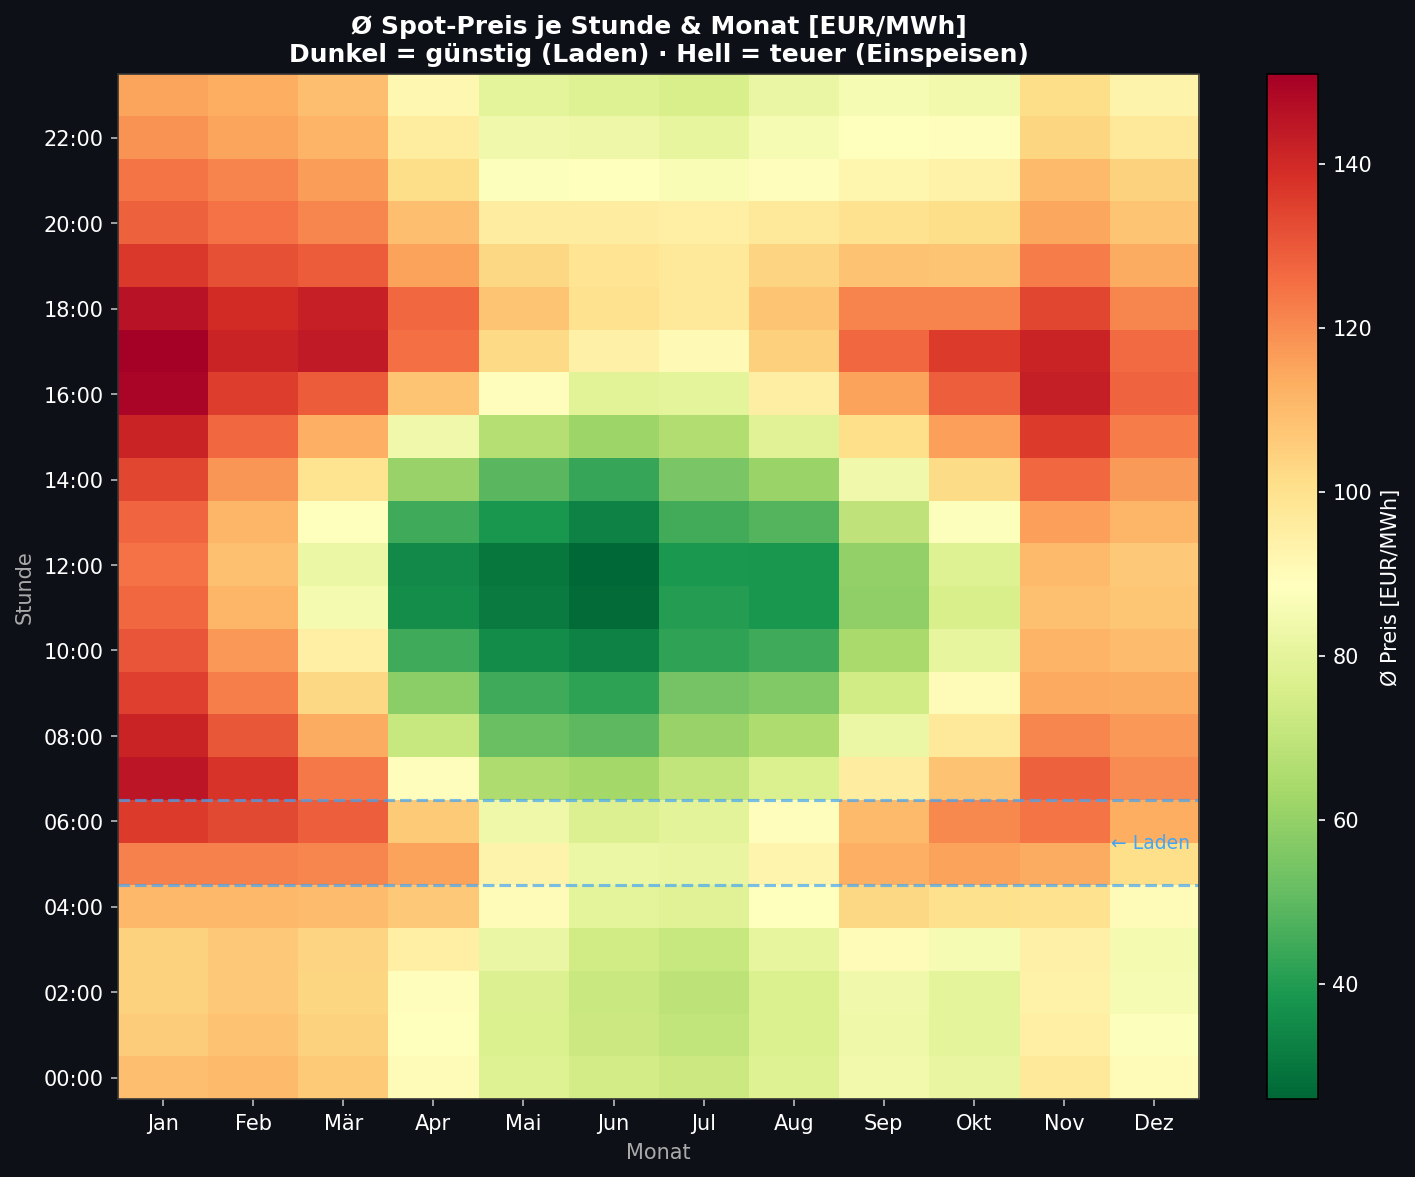


Chart 2: Ø Spot-Preis CH — Stunde × Monat 2023–2024



In [10]:
show_chart('nb04_heatmap_preis.png',
           'Chart 2: Ø Spot-Preis CH — Stunde × Monat 2023–2024', width=900)

**Interpretation Heatmap:** Die Farbcodierung zeigt das Arbitrage-Potenzial direkt: **Grüne Felder** (günstige Stunden) sind das optimale Ladefenster, **dunkle/rote Felder** das Einspeisefenster. Zwei Muster stechen hervor:

- **Sommer-Mittag (10–14 Uhr, Juni–August):** Tiefste Durchschnittspreise des Jahres durch Solar-Überproduktion — ideales Ladefenster. Im Extremfall entstehen hier Negativpreise.
- **Abendspitze (17–21 Uhr, Okt–Feb):** Höchste Durchschnittspreise durch gleichzeitige Heiz- und Berufslast — ideales Einspeisefenster.

Der **Frühling (März–Mai)** zeigt dabei die grösste Preisspanne zwischen Mittag und Abend — die [Duck Curve](../organisation/O_02_Glossar.ipynb#g-duck-curve) ist in dieser Jahreszeit am ausgeprägtesten.

### 3.2 Tagesprofil: Netzlast & Arbitrage-Fenster

Chart 3 zeigt die zeitliche Überlagerung von Netzlast und Preis: Das **Ladefenster (blau, ~09–13 Uhr)** fällt ins Solar-Mittagstief, wenn Preise und Netzlast tief sind. Das **Einspeisefenster (rot, ~15–20 Uhr)** trifft die Abendspitze — genau dann ist die Netzlast am höchsten und der Beitrag zur [Netzentlastung](../organisation/O_02_Glossar.ipynb#g-netzentlastung) am grössten.


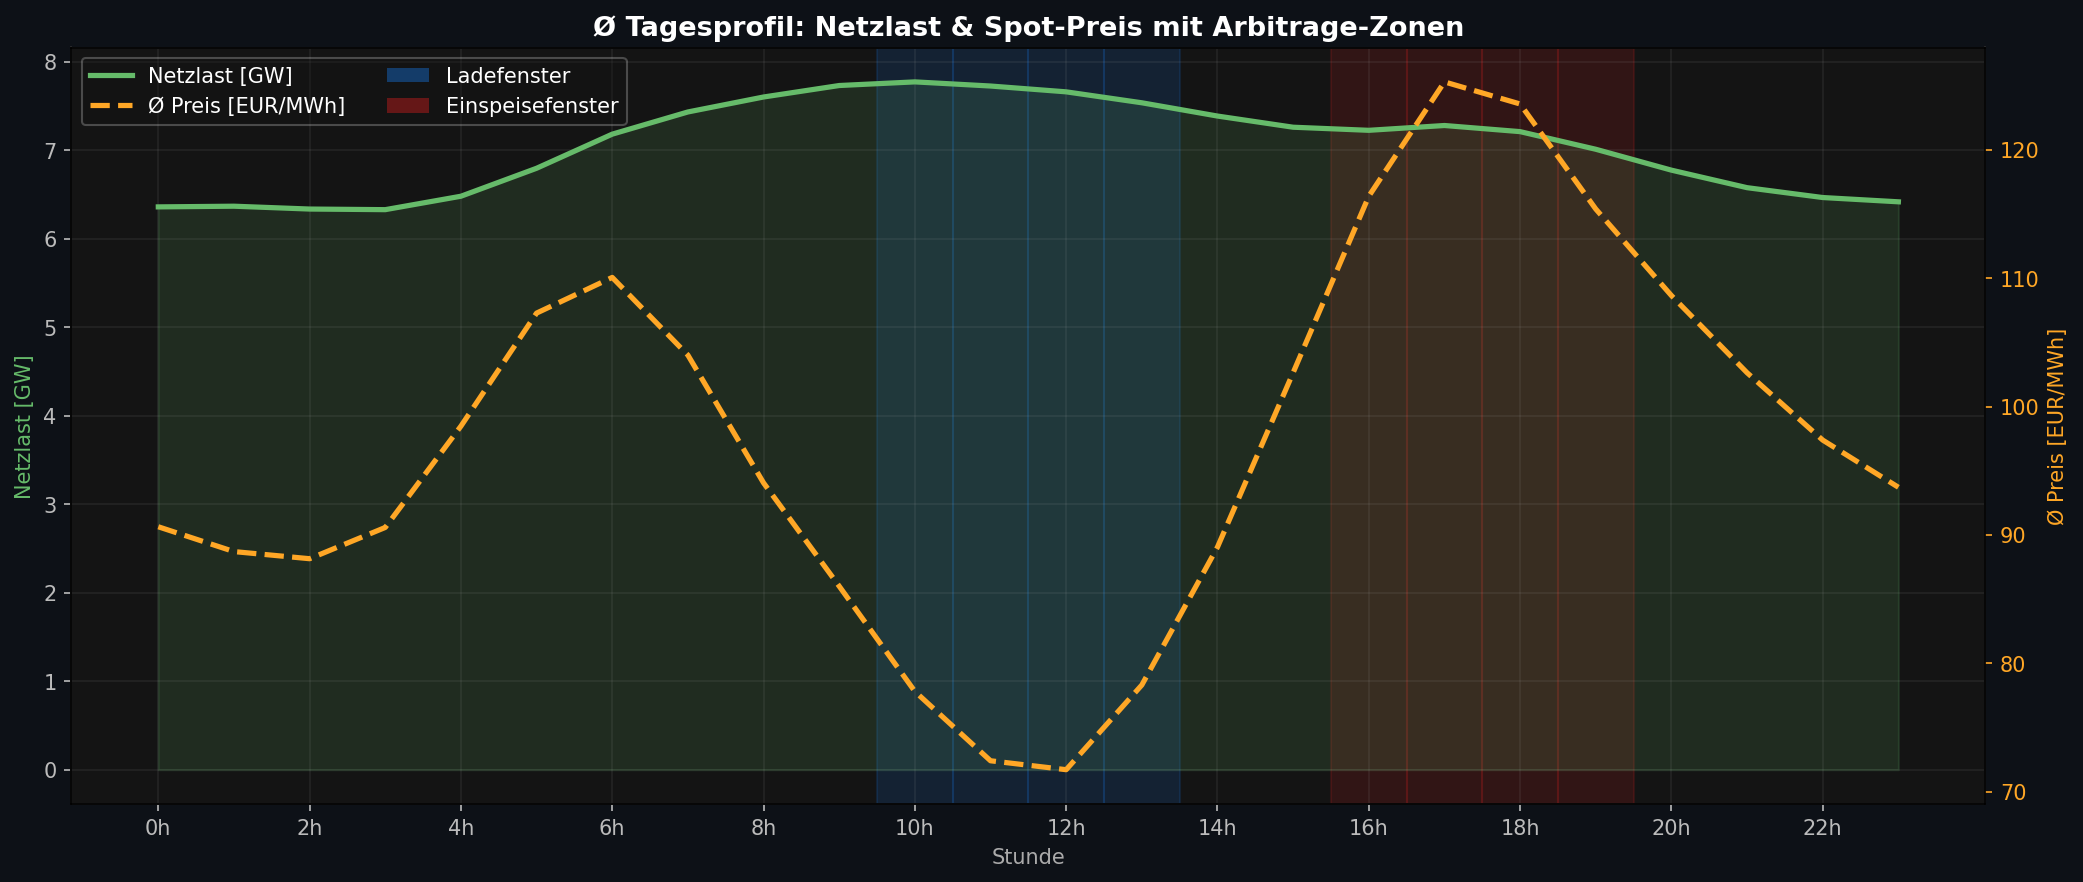


Chart 3: Ø Tagesprofil Netzlast & Spot-Preis mit Arbitrage-Fenstern



In [11]:
show_chart('nb04_tagesprofil_einzel.png',
           'Chart 3: Ø Tagesprofil Netzlast & Spot-Preis mit Arbitrage-Fenstern', width=900)

### 3.3 Wirtschaftlichkeit

Die folgenden Charts zeigen die Wirtschaftlichkeit aus vier Winkeln. Alle Zahlen basieren **ausschliesslich auf Arbitrage-Erlösen** — Regelenergiemarkt (FCR/aFRR), Peak-Shaving-Prämien und [Erlösstacking](../organisation/O_02_Glossar.ipynb#g-erloess-stacking) sind nicht eingerechnet.

**Kernergebnis:** Kein Segment erreicht den Ziel-[ROI](../organisation/O_02_Glossar.ipynb#g-roi) von 8.33%⚙ p.a. bei reiner Arbitrage. Industrie liegt mit 4.6%📊 am nächsten, Privat mit 1.8%📊 am weitesten entfernt. Keines der Segmente erreicht den Break-Even innerhalb der modellierten 12 Jahre⚙ — auch auf 20 Jahre⚙ (Chart 1e) bleibt der kumulierte Cashflow negativ.


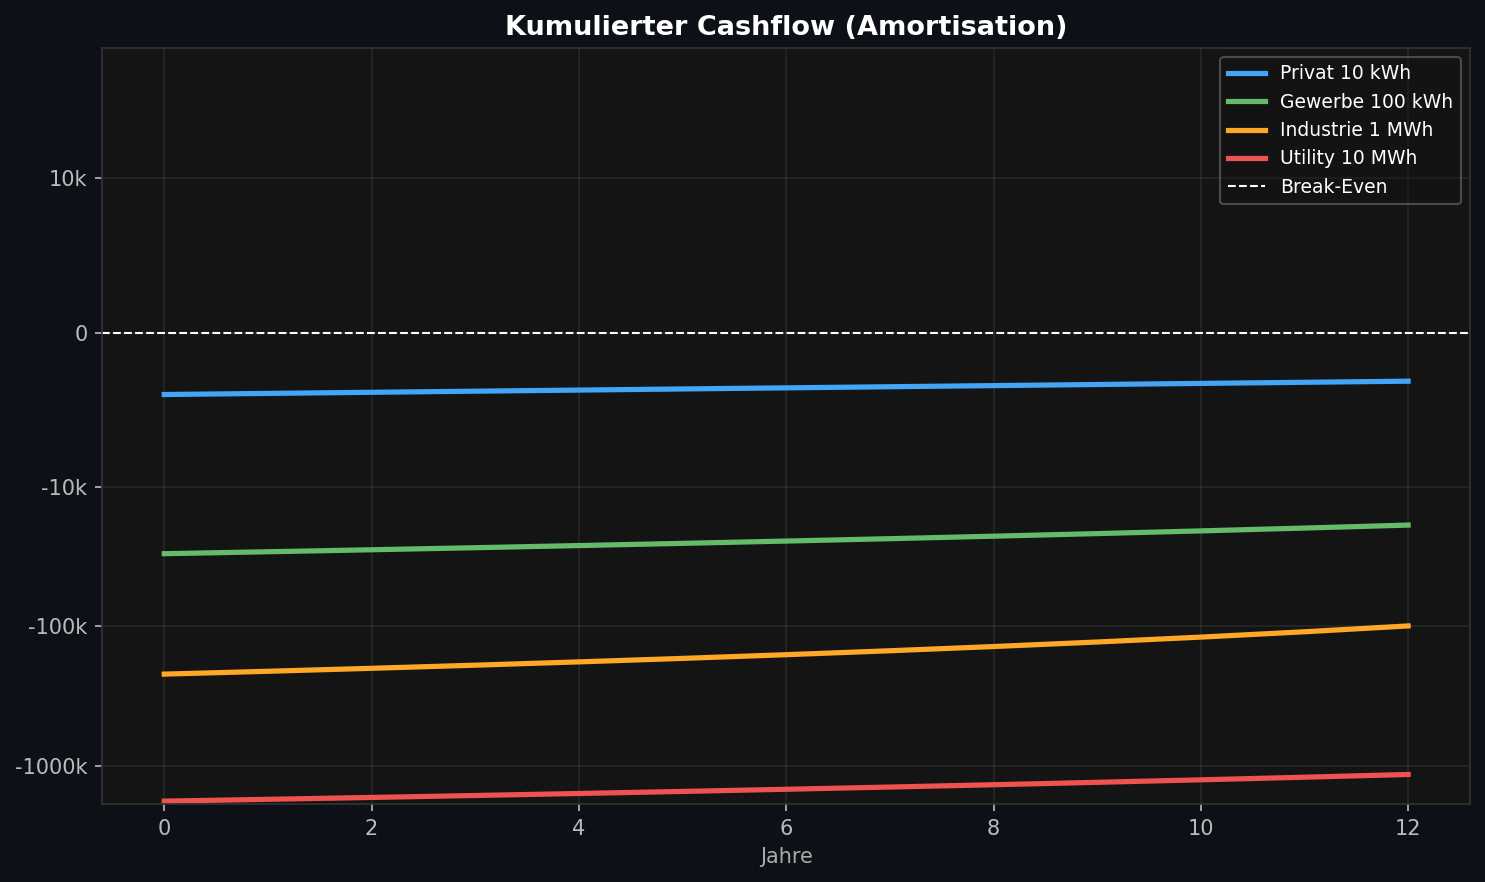


Amortisationskurven: kumulierter Cashflow über 12 Jahre



In [12]:
show_chart('nb04_amortisation.png',
           'Amortisationskurven: kumulierter Cashflow über 12 Jahre', width=900)

**Interpretation Amortisation:** Alle vier Kurven starten im negativen Bereich (CAPEX-Auszahlung) und steigen linear an. Keine Kurve schneidet die Nulllinie innerhalb von 12 Jahren — kein Segment erreicht den Break-Even in der modellierten Lebensdauer. Utility startet am tiefsten (−1'800 kEUR) und steigt am steilsten, bleibt aber auch nach 12 Jahren noch tief im negativen Bereich. Die [symlog](../organisation/O_02_Glossar.ipynb#g-symlog)-Y-Achse ermöglicht, alle vier Grössenordnungen (4 kEUR bis 1'800 kEUR CAPEX) gleichzeitig sichtbar zu machen.

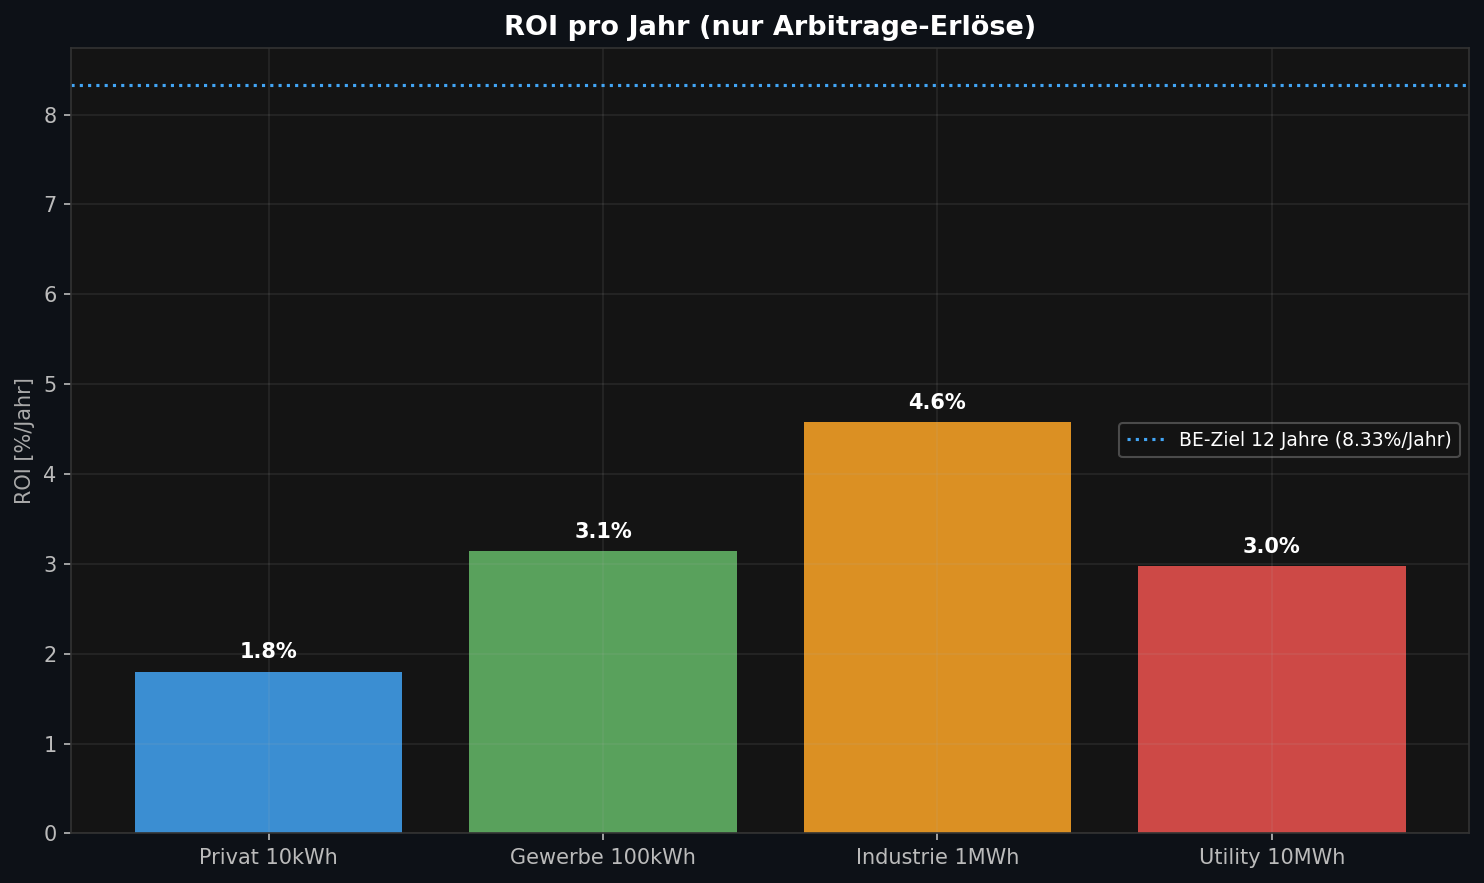


ROI pro Jahr nach Segment (nur Arbitrage-Erlöse)



In [13]:
show_chart('nb04_roi.png',
           'ROI pro Jahr nach Segment (nur Arbitrage-Erlöse)', width=900)

**Interpretation ROI:** Die gestrichelte Linie markiert den **Break-Even-ROI von 8.33%⚙/Jahr** (= Lebensdauer 12 Jahre⚙ amortisiert). Kein Segment erreicht ihn: Industrie kommt mit **4.6%📊** am nächsten, Privat bleibt bei **1.8%📊**. Der scheinbare Paradox — Utility hat höchsten Absoluterlös aber nur 3.0%📊 ROI — erklärt sich durch den proportional noch höheren CAPEX (180 EUR/kWh × 10'000 kWh = 1.8 Mio EUR). Der ROI-Chart zeigt klar: Das Problem ist nicht die Technik, sondern das **Verhältnis von Spread-Niveau zu CAPEX-Niveau** unter aktuellen CH-Marktbedingungen.

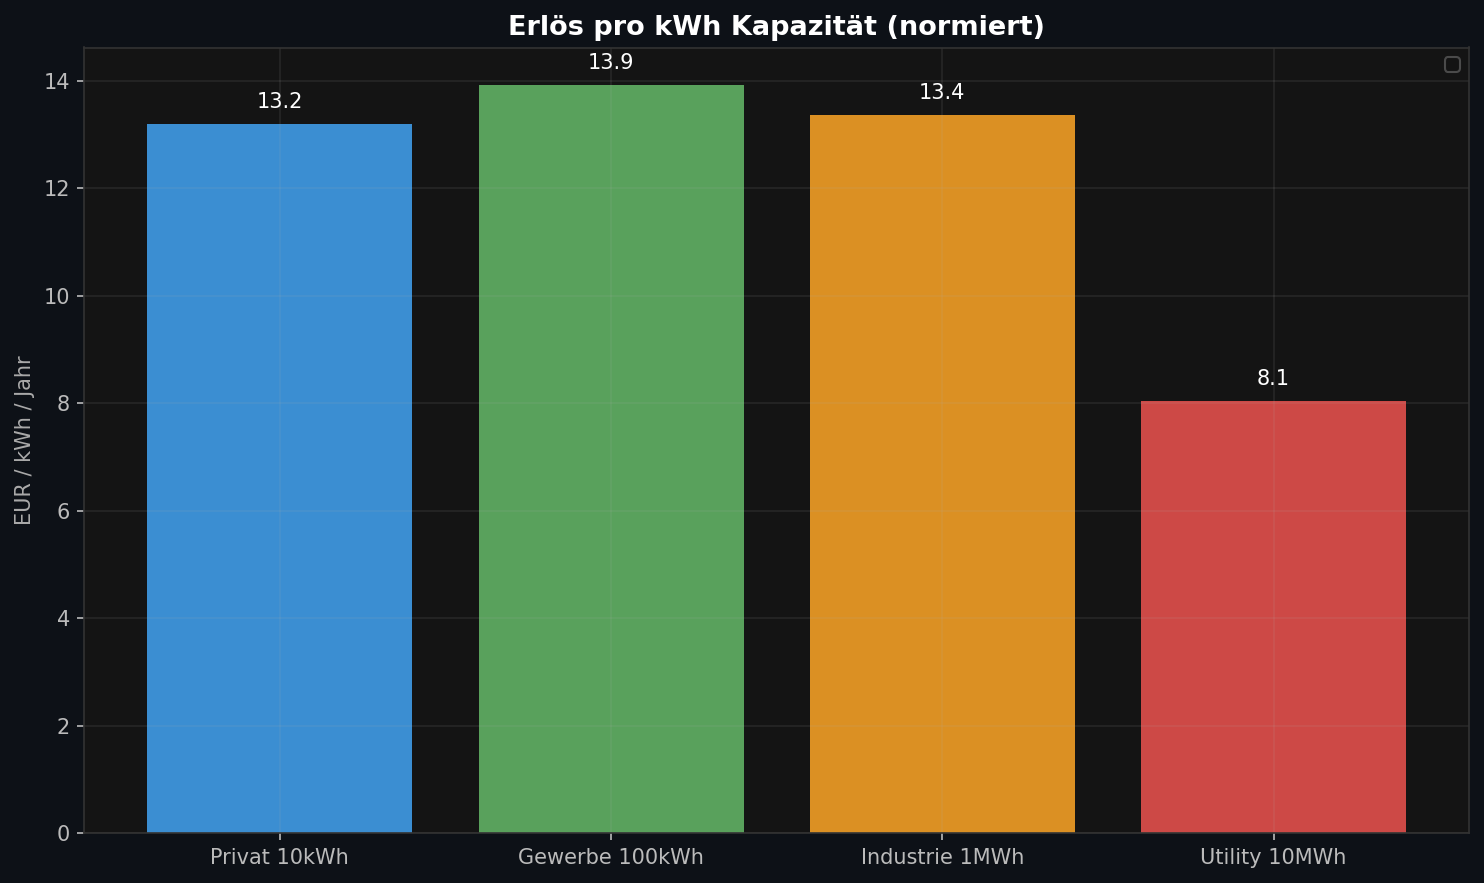


Erlös pro kWh Kapazität — normierter Segmentvergleich



In [14]:
show_chart('nb04_erloese_kwh.png',
           'Erlös pro kWh Kapazität — normierter Segmentvergleich', width=900)

**Erlös pro kWh (normiert):** Dieser Chart macht Segmente grössenunabhängig vergleichbar — alle Segmente erzielen ~13 EUR pro installierter kWh Kapazität pro Jahr. Ausnahme: **Utility (8.0 EUR/kWh📊)** schneidet schlechter ab. Der Grund liegt in der [C-Rate](../organisation/O_02_Glossar.ipynb#g-c-rate): Bei 10 MWh und 1 MW Konverterleistung (C-Rate 0.1C) kann die Batterie in einem typischen 2-Stunden-Preisspread-Fenster nur 20% ihrer Kapazität nutzen. Gewerbe (13.9 EUR/kWh📊) mit C-Rate 0.3C nutzt das Preisspread-Fenster am effizientesten.

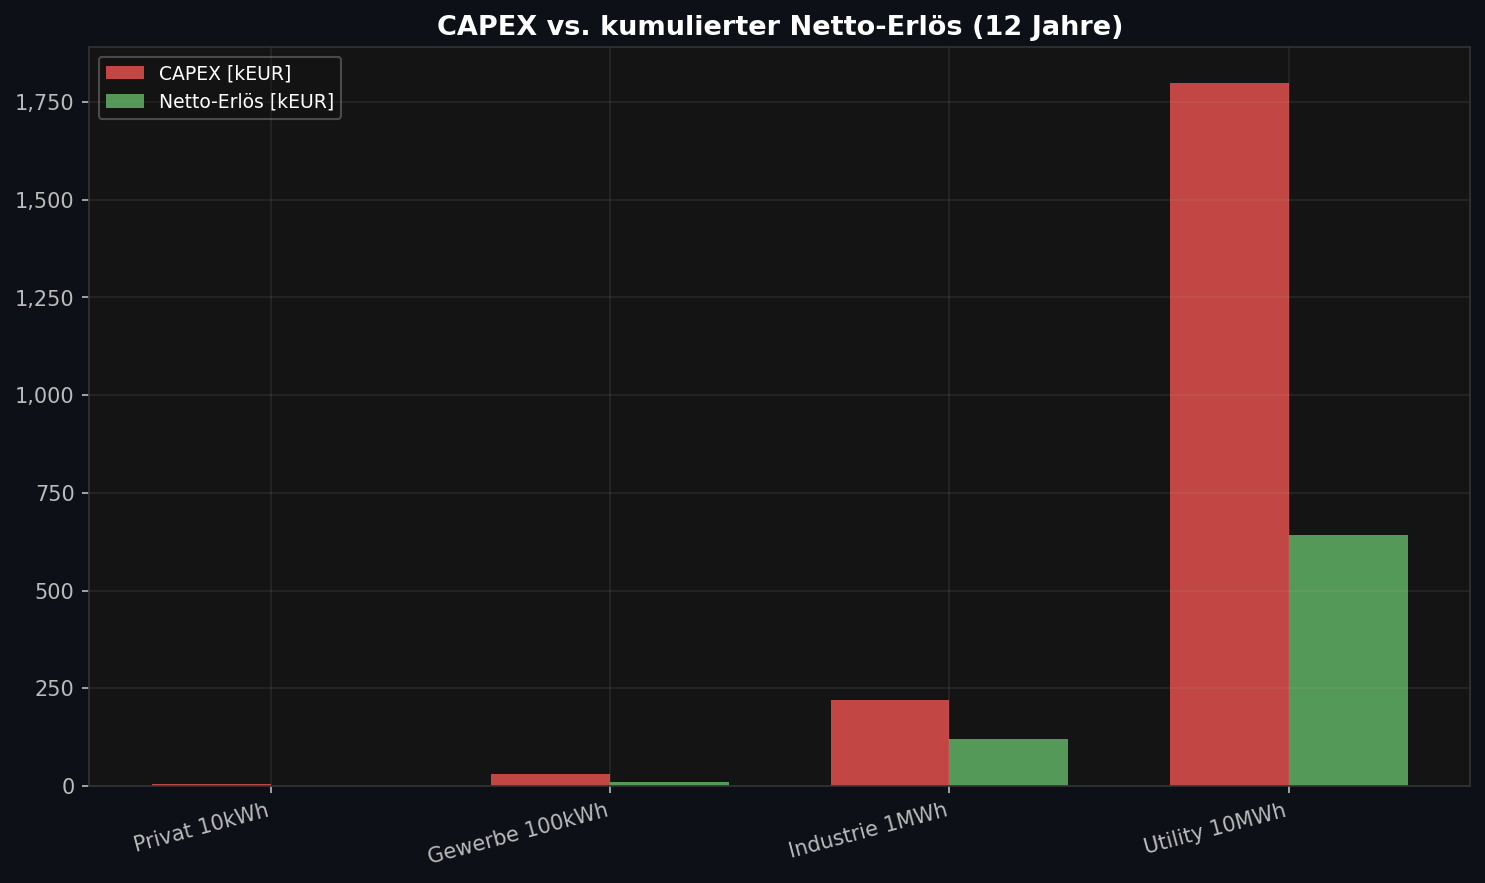


CAPEX vs. kumulierter Netto-Erlös (12 Jahre)



In [15]:
show_chart('nb04_capex_ertrag.png',
           'CAPEX vs. kumulierter Netto-Erlös (12 Jahre)', width=900)

**[CAPEX](../organisation/O_02_Glossar.ipynb#g-capex) vs. kumulierter Netto-Erlös (12 Jahre):** Dieser Chart zeigt das strukturelle Kernproblem in absoluten Zahlen. Bei Utility stehen **1'800 kEUR CAPEX** einer kumulierten Netto-Einnahme von ~**637 kEUR**📊 (12 Jahre) gegenüber — die Investition wird zu ~35.4%📊 zurückverdient. Industrie steht am besten: **220 kEUR CAPEX** vs. ~**120 kEUR**📊 Netto über 12 Jahre (~54.7%📊 Rückfluss). Für vollständige Rentabilität bräuchte es entweder einen 2–3× höheren Spread oder ~60% tiefere CAPEX — oder beides kombiniert mit [Erlösstacking](../organisation/O_02_Glossar.ipynb#g-erloess-stacking).

### 3.4 Netzentlastungs-Potenzial

Aggregierte Batterien können die Schweizer Spitzenlast (Basis: 10.5 GW⚙) messbar reduzieren. Die Wirkung steigt stark mit dem [Rollout-Szenario](../organisation/O_02_Glossar.ipynb#g-rollout-szenario): Von 1.3%📊 (Moderat, 2027) bis 20.2%📊 (Transformativ, 2035).

> **Gleichzeitigkeits-Annahme:** Die Ergebnisse basieren auf dem aktiven Szenario in `../sync/config.json → szenarien.gleichzeitigkeit_aktiv`. Zum Umschalten: Wert ändern → NB02 + NB03 neu ausführen → Charts aktualisieren sich automatisch.


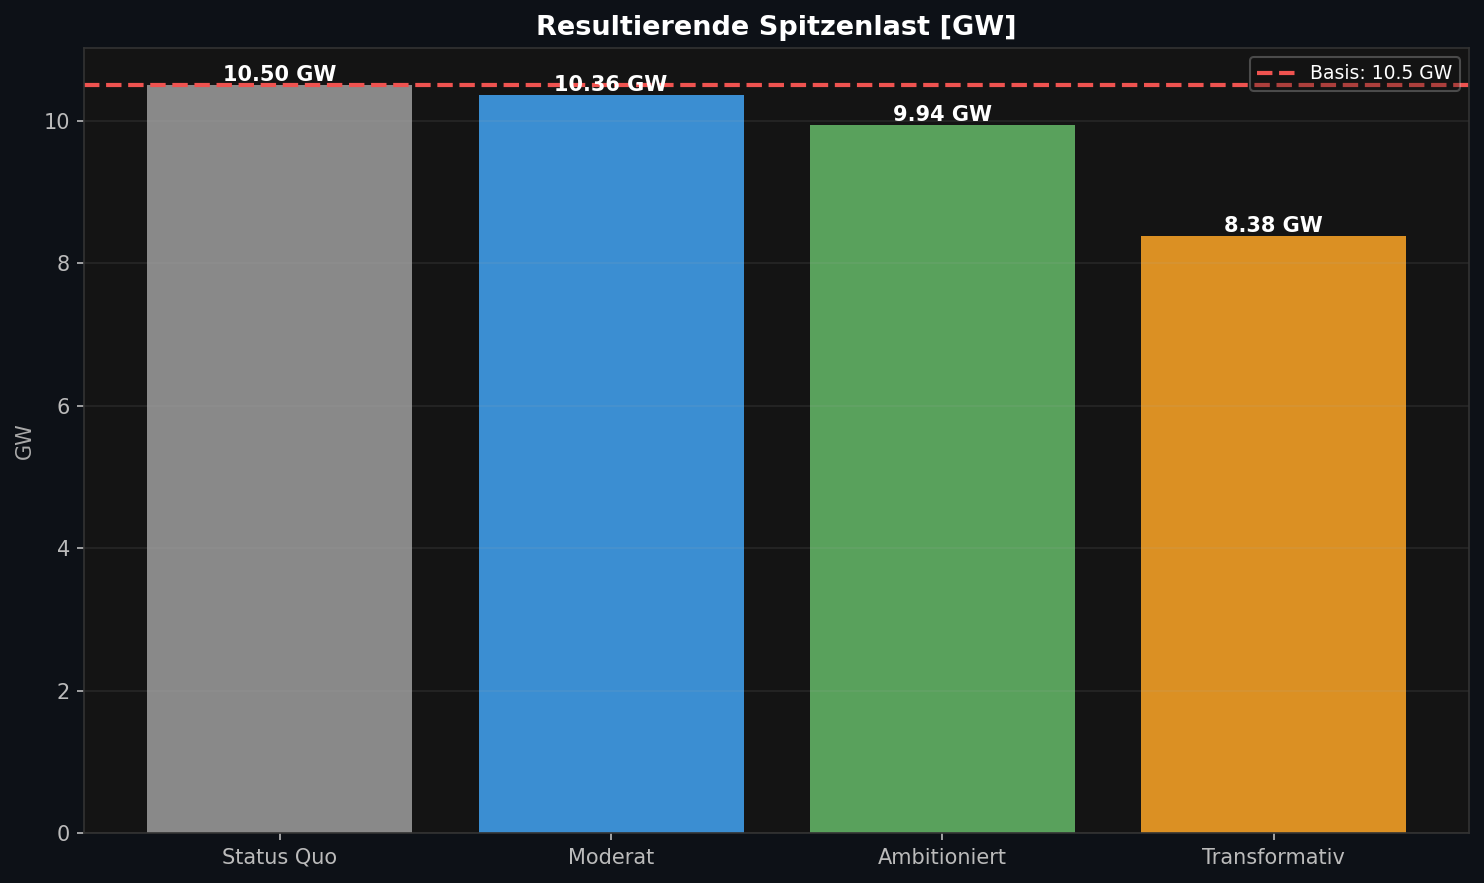


Resultierende Spitzenlast je Szenario [GW]



In [16]:
show_chart('nb04_spitzenlast.png',
           'Resultierende Spitzenlast je Szenario [GW]', width=800)

In [17]:
# Gleichzeitigkeit-Info aus den geladenen Szenarien
if _gz_mode != 'unbekannt':
    print(f'Gleichzeitigkeit (aus NB2): {_gz_mode} ({_gz_rate})')
    if _gz_mode == 'realistisch':
        print('  → 40% der Batterien dispatchen gleichzeitig (unkoordinierter Markt)')
        print('  → Zum Vergleich: optimistisch = 70% (VPP-koordiniert) ergibt ~1.75× höhere Entlastung')
    else:
        print('  → 70% der Batterien dispatchen gleichzeitig (VPP-koordinierter Dispatch)')
        print('  → Zum Vergleich: realistisch = 40% (unkoordiniert) ergibt ~0.57× der Entlastung')


Gleichzeitigkeit (aus NB2): realistisch (40%)
  → 40% der Batterien dispatchen gleichzeitig (unkoordinierter Markt)
  → Zum Vergleich: optimistisch = 70% (VPP-koordiniert) ergibt ~1.75× höhere Entlastung


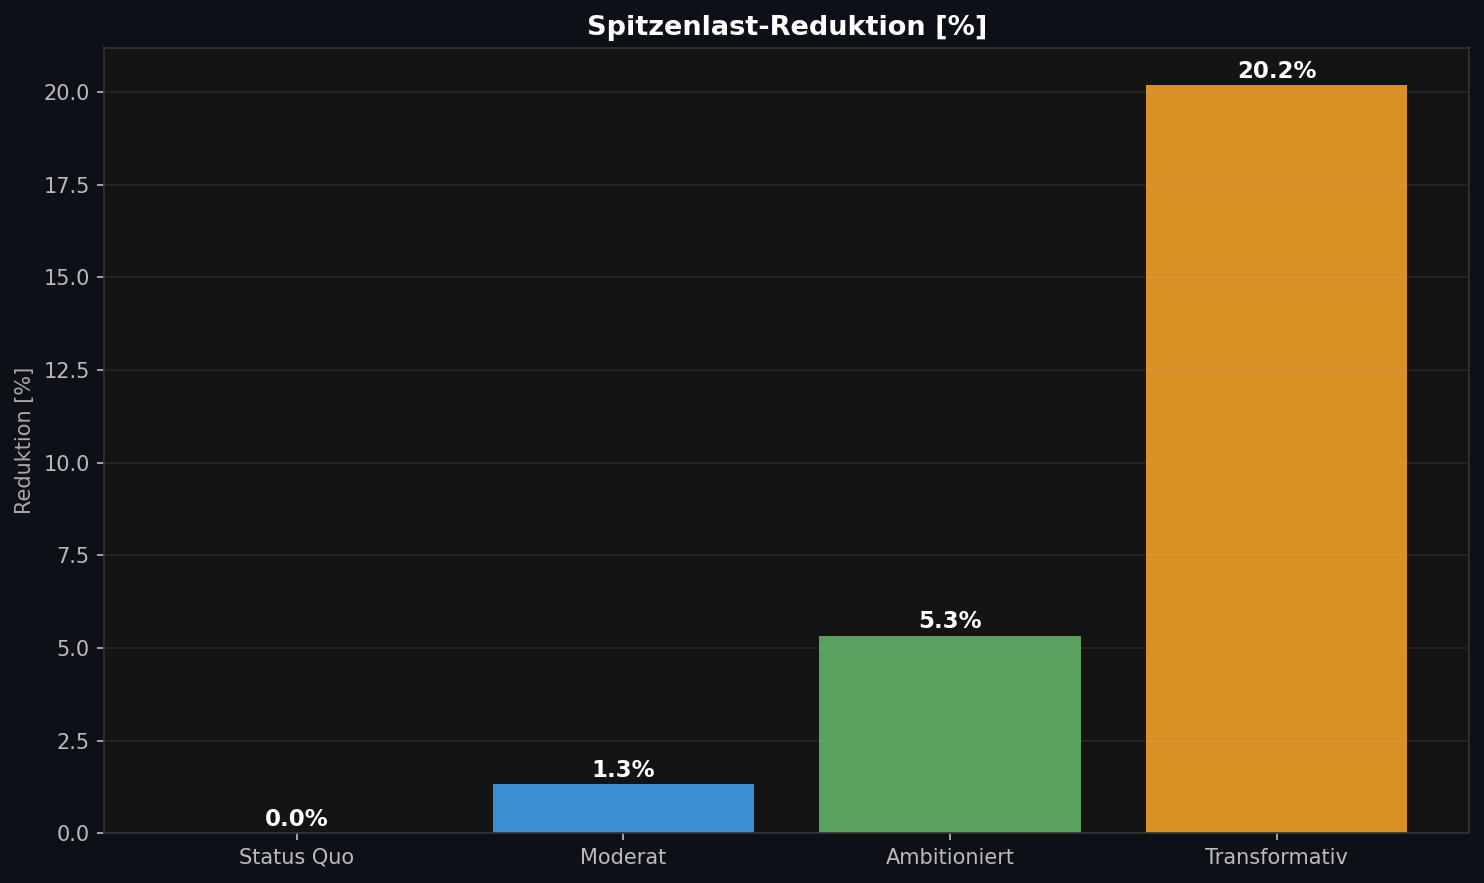


Spitzenlast-Reduktion [%] je Szenario



In [18]:
show_chart('nb04_spitzenlast_reduktion.png',
           'Spitzenlast-Reduktion [%] je Szenario', width=800)

**Interpretation [Netzentlastung](../organisation/O_02_Glossar.ipynb#g-netzentlastung):** Die Szenarien zeigen einen exponentiellen Effekt: Erst ab dem **[Transformativ-Szenario](../organisation/O_02_Glossar.ipynb#g-rollout-szenario)** (2035: 800'000⚙ Privat, 2'000⚙ Industrie-Einheiten) wird die Systemwirkung für Swissgrid wirklich relevant — 20.2%📊 Spitzenlastreduzierung ist eine Grösse, die Netzausbauinvestitionen verschiebt oder verhindert. Das [Moderat-Szenario](../organisation/O_02_Glossar.ipynb#g-rollout-szenario) (2027) bleibt mit 1.3%📊 systemisch kaum spürbar. Entscheidend ist die **Gleichzeitigkeitsannahme** (40%⚙ realistisch): Nicht alle Batterien entladen gleichzeitig — koordinierter [VPP](../organisation/O_02_Glossar.ipynb#g-vpp)-Dispatch würde bis zu 70%⚙ erreichen und die Kurven entsprechend steiler machen.

### 3.5 Saisonale Rentabilität

Der Arbitrage-Spread variiert stark saisonal — entgegen der Erwartung ist **Frühling** die renditestärkste Saison, nicht Winter. Die Kombination aus noch hoher Heizlast und früher Solarproduktion erzeugt den grössten Intra-Tag-Preisunterschied.

> ⚠️ **Begriffsklarstellung:** Diese Tabelle verwendet zwei verschiedene Spread-Grössen — sie sind **nicht direkt vergleichbar**:
> - **[Marktpreisspanne (max−min)](../organisation/O_02_Glossar.ipynb#g-marktpreisspanne):** Mittlere tägliche Differenz (Höchst- minus Tiefstpreis), gemittelt über die Saison. Theoretische Obergrenze; setzt perfektes Timing *und* unbegrenzte Konverterleistung voraus (real limitiert durch C-Rate — z.B. 5 kW / 10 kWh = C-Rate 0.5 → max. 50% der Kapazität pro Stunde nutzbar).
> - **[Simulierter Monatserlös](../organisation/O_02_Glossar.ipynb#g-intra-tag-spread) (p75−p25-Basis):** Tatsächlich erzielbarer Erlös aus der [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch)-Simulation pro MWh Kapazität und Monat. Basis für den Rentabilitäts-Trigger (> 30 EUR/MWh⚙, vgl. K_03).

| Saison | Ø Marktpreisspanne (max−min) | Simulierter Monatserlös (Chart 5b) | Charakteristik |
|--------|------------------------------|-------------------------------------|----------------|
| **Frühling** | ~84 EUR/MWh📊 | Mai: ~38 EUR/MWh·Monat📊 (Maximum) | Höchste Arbitrage-Rendite |
| Sommer | ~75 EUR/MWh📊 | Jul–Aug: ~22–25 EUR/MWh·Monat📊 | Viele Negativpreise (Ladechancen) |
| Winter | ~49 EUR/MWh📊 | Dez–Feb: ~20 EUR/MWh·Monat📊 | Gleichmässiger, geringerer Spread |
| Herbst | ~70 EUR/MWh📊 | Sep–Okt: ~21–26 EUR/MWh·Monat📊 | Übergangsphase |

**Negativpreise** treten hauptsächlich im Frühjahr/Sommer auf (Apr–Jun) — dort kann die Batterie kostenlos laden und erhöht damit den effektiven Erlös. Im Winter sind Negativpreise selten.


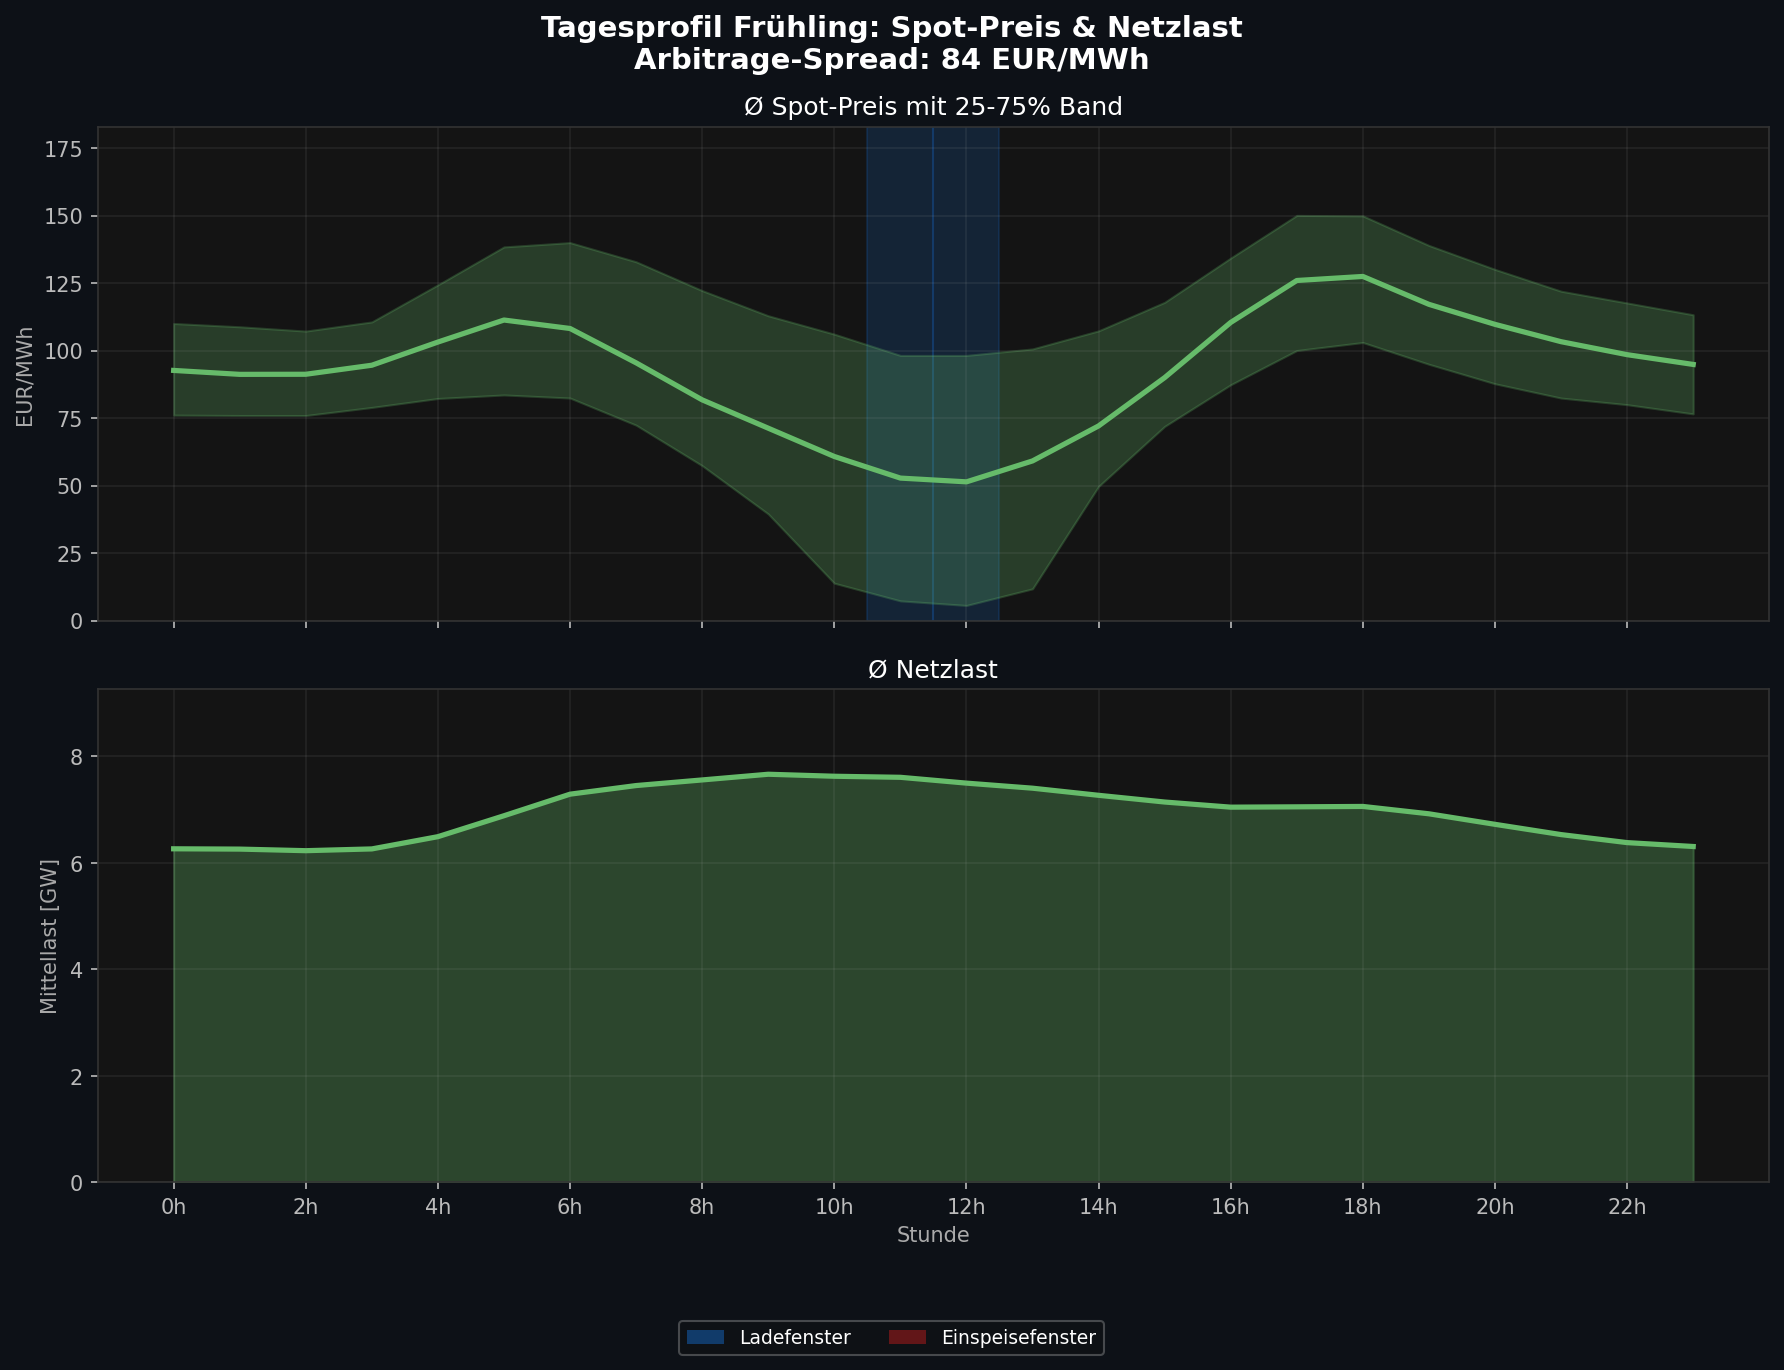


Frühling-Tagesprofil: Höchster Spread (139 EUR/MWh) — optimale Arbitrage-Bedingungen



In [19]:
show_chart('nb04_saisonal_frühling.png',
           'Frühling-Tagesprofil: Höchster Spread (139 EUR/MWh) — optimale Arbitrage-Bedingungen', width=900)

**Frühling (März–Mai):** Die renditestärkste Saison mit ~84 EUR/MWh Marktpreisspanne (max−min) und simulierten Monatserlösen bis ~38 EUR/MWh im Mai. Der Grund ist der **[Duck-Curve-Effekt](../organisation/O_02_Glossar.ipynb#g-duck-curve)** in seiner stärksten Form: Solar ist bereits aktiv (Mittagstief), aber die Heizlast ist noch hoch (Abendspitze) — die Preisspanne zwischen Tief und Hoch ist maximal. Der Frühlings-Abend (19:00 Uhr) ist der rentabelste Einspeisezeitpunkt des ganzen Jahres.

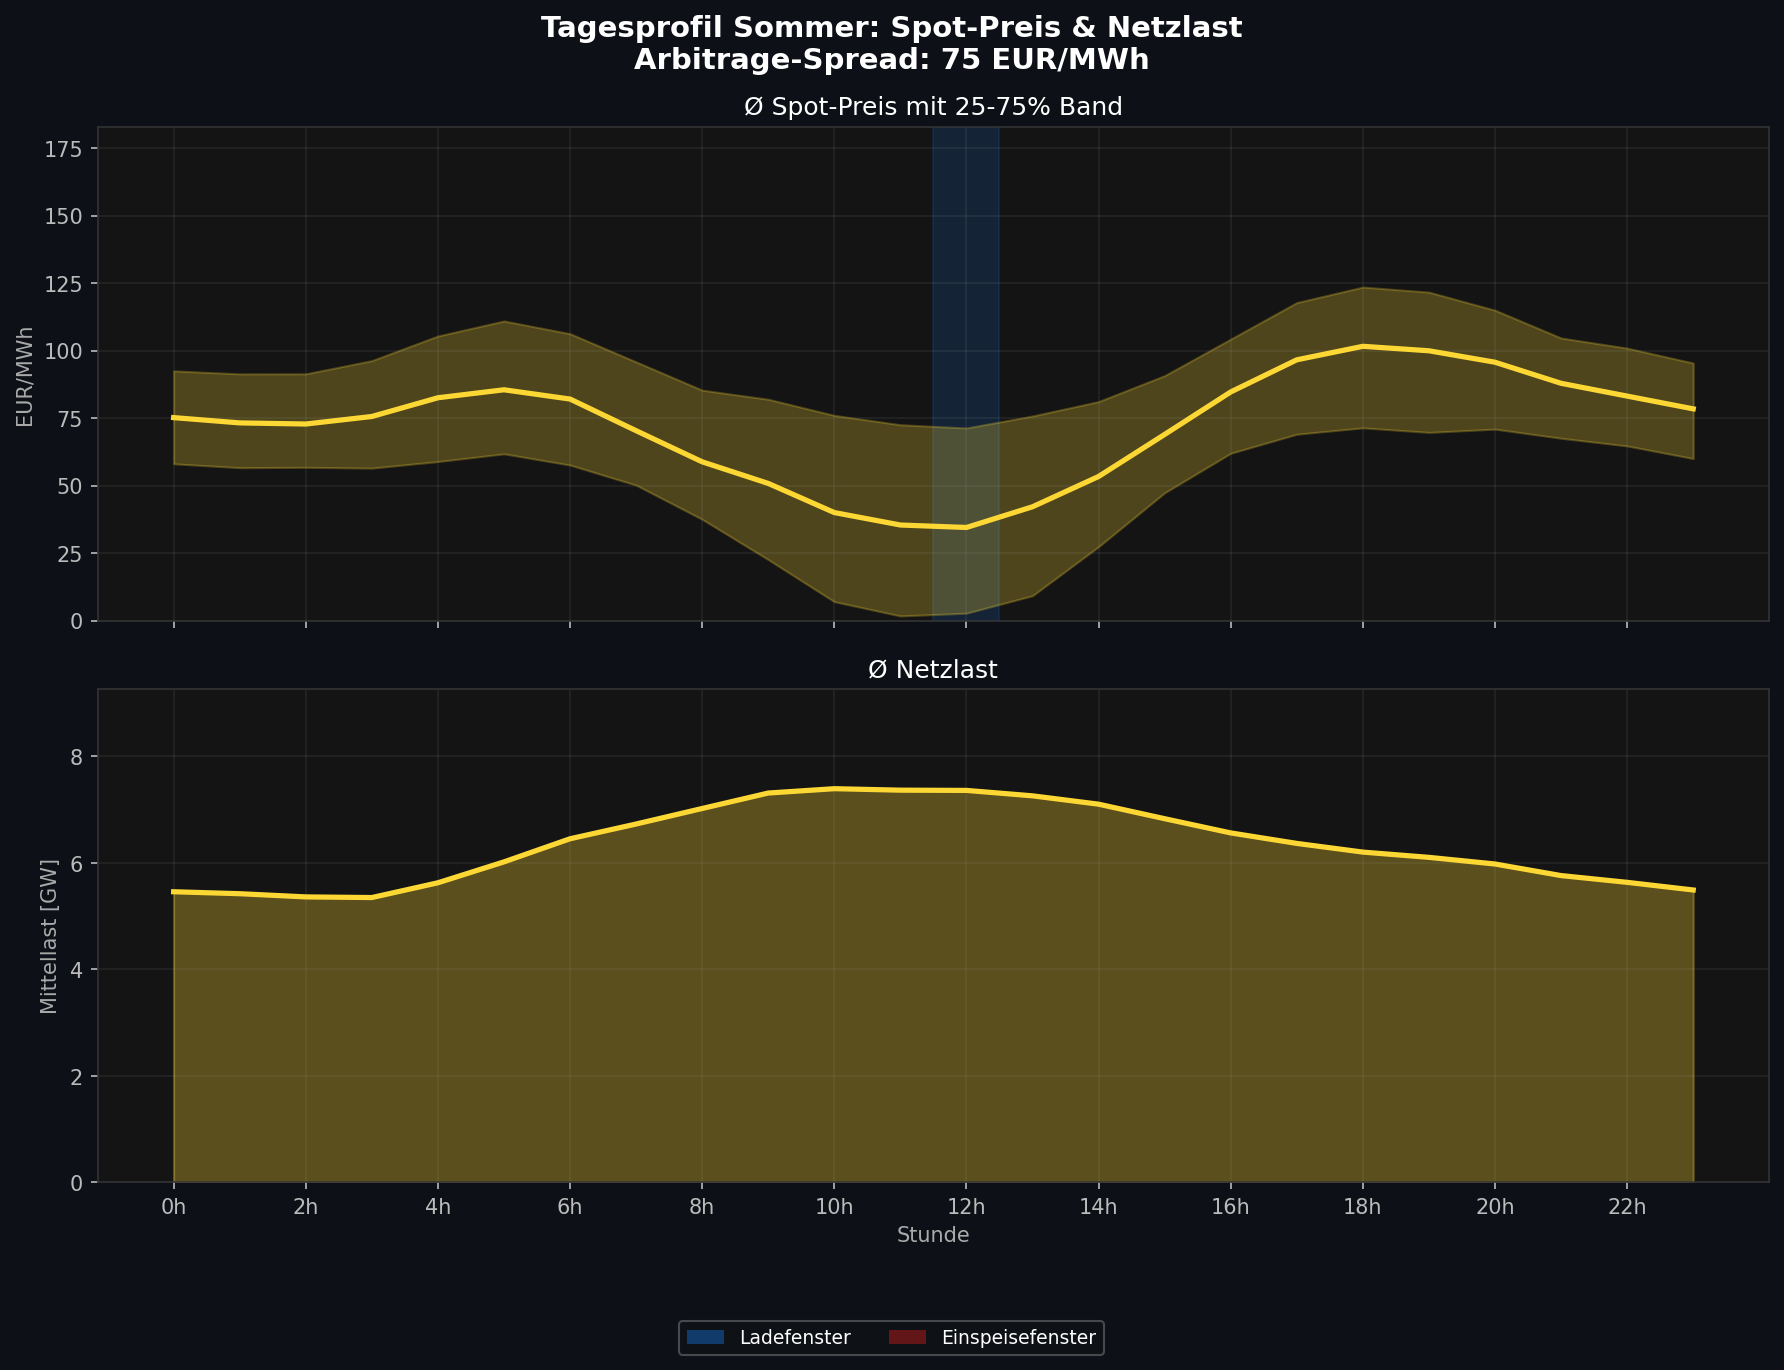


Sommer-Tagesprofil: Solar-Mittagstief erzeugt Negativpreise — kostenlose Ladezyklen



In [20]:
show_chart('nb04_saisonal_sommer.png',
           'Sommer-Tagesprofil: Solar-Mittagstief erzeugt Negativpreise — kostenlose Ladezyklen', width=900)

**Sommer (Juni–August):** Das Solar-Mittagstief (10–14 Uhr) erzeugt zeitweise **Negativpreise** (~18 Stunden/Jahr📊 im Schnitt) — die Batterie lädt in diesen Stunden gratis und wird sogar für die Aufnahme vergütet. Das Ladefenster verschiebt sich auf den Mittag statt in die Nacht. Der effektive Erlös steigt dadurch trotz moderatem Tagesspread: Die Ladekostenersparnis bei Negativpreisen ist ein echter Bonus. Sommer-Arbitrage erfordert einen saisonal adaptierten [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch)-Algorithmus — ein statisches Nacht-Ladefenster verpasst den Grossteil des Potenzials.

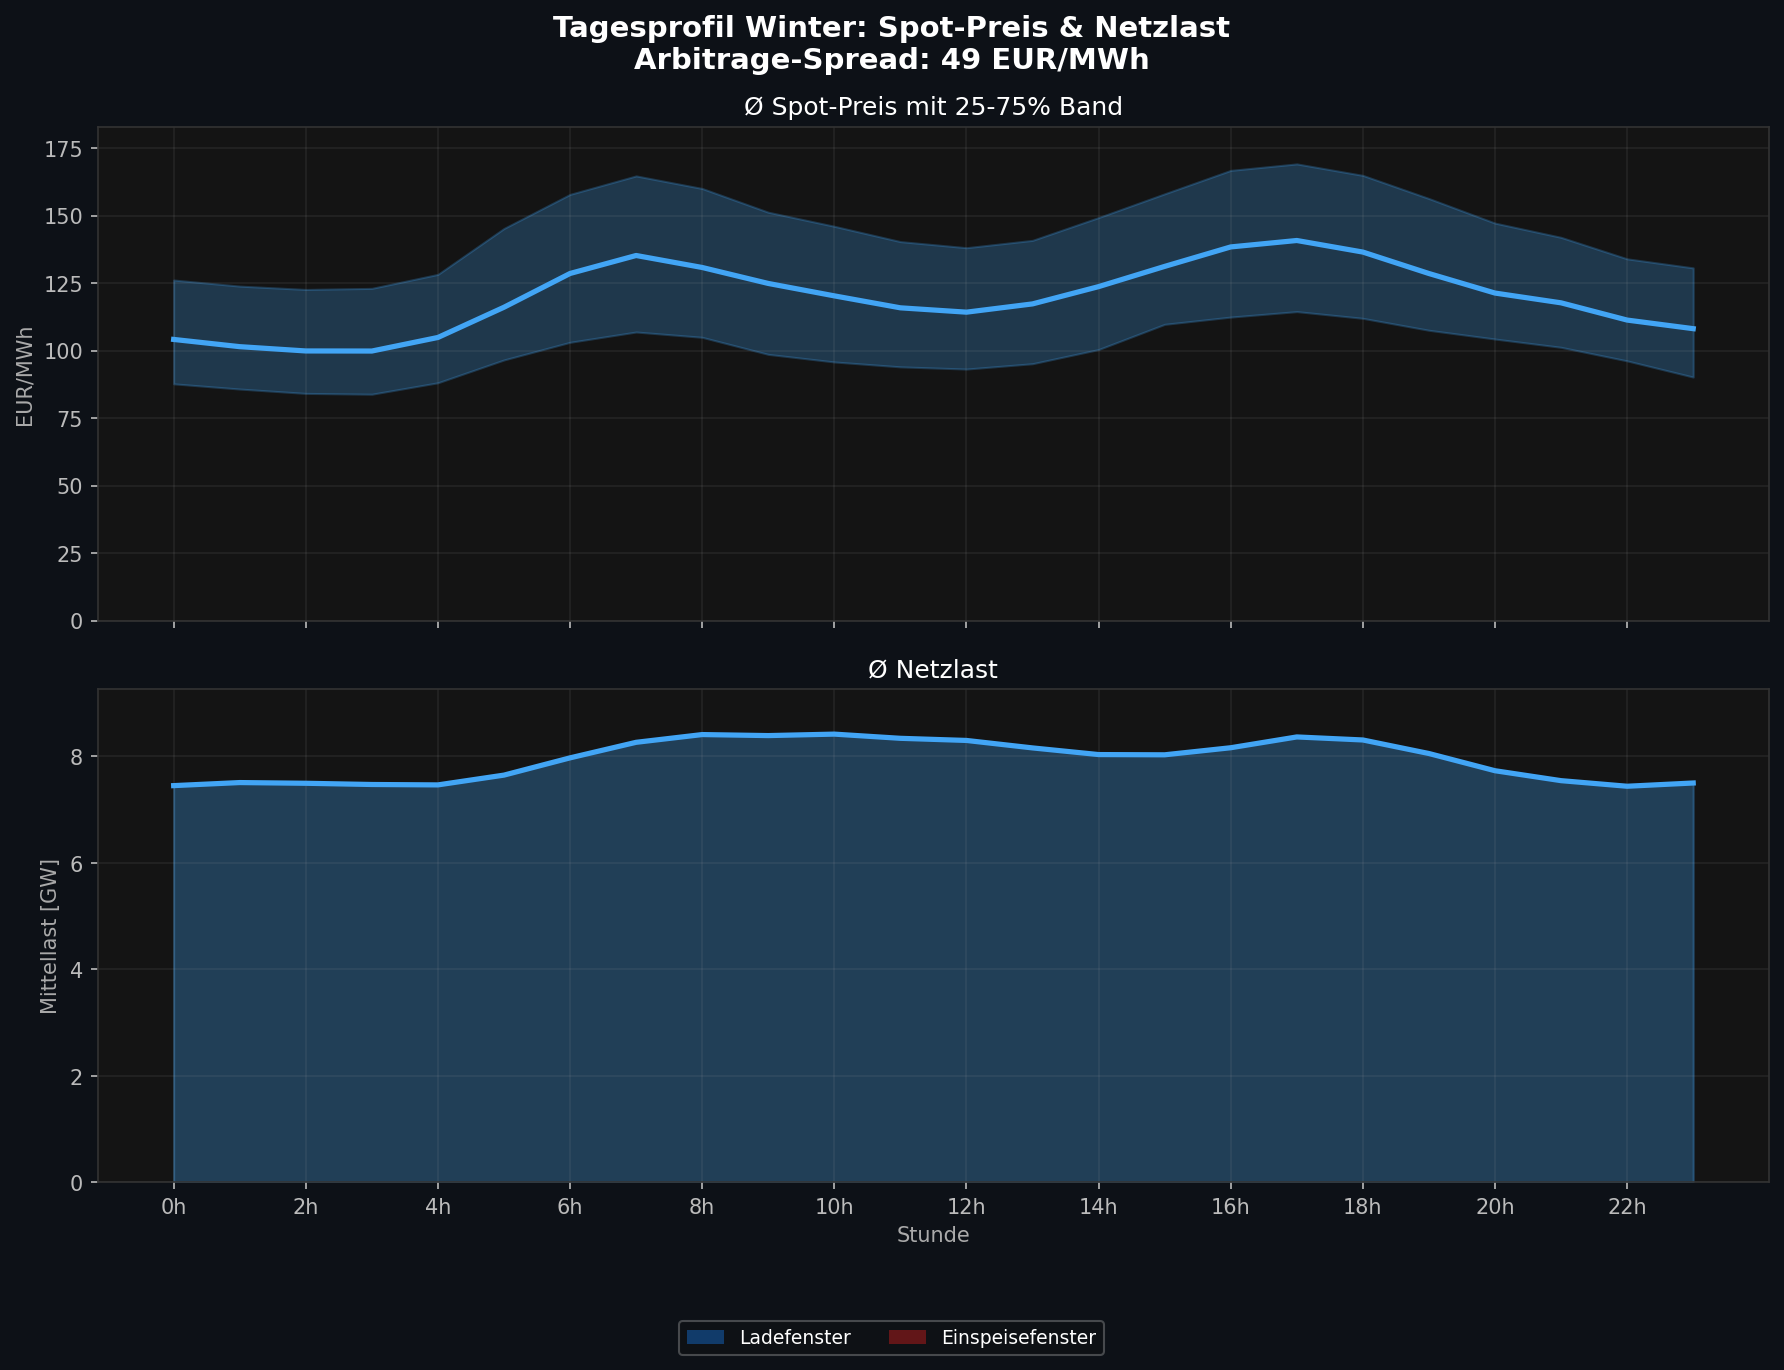


Winter-Tagesprofil: Geringster Spread (85 EUR/MWh) — Kontrastbeispiel zur renditeschwächsten Saison



In [21]:
show_chart('nb04_saisonal_winter.png',
           'Winter-Tagesprofil: Geringster Spread (85 EUR/MWh) — Kontrastbeispiel zur renditeschwächsten Saison', width=900)

**Winter (Dezember–Februar):** Mit ~49 EUR/MWh Marktpreisspanne (max−min) ist der Winter die renditeschwächste Saison — entgegen der intuitiven Erwartung. Die Nachfrage ist zwar hoch (Heizung), aber das Angebot ist gleichmässiger, weil Pumpspeicher regulär einspeisen und keine extremen Solar-Mittagstäler entstehen. Der simulierte Monatserlös liegt bei ~20 EUR/MWh, das Ladefenster verschiebt sich auf die frühen Morgenstunden (02–06 Uhr). Winter zeigt, dass Preisniveau allein nicht reicht — es braucht **zeitliche Preisvolatilität**, nicht nur hohes Preisniveau.

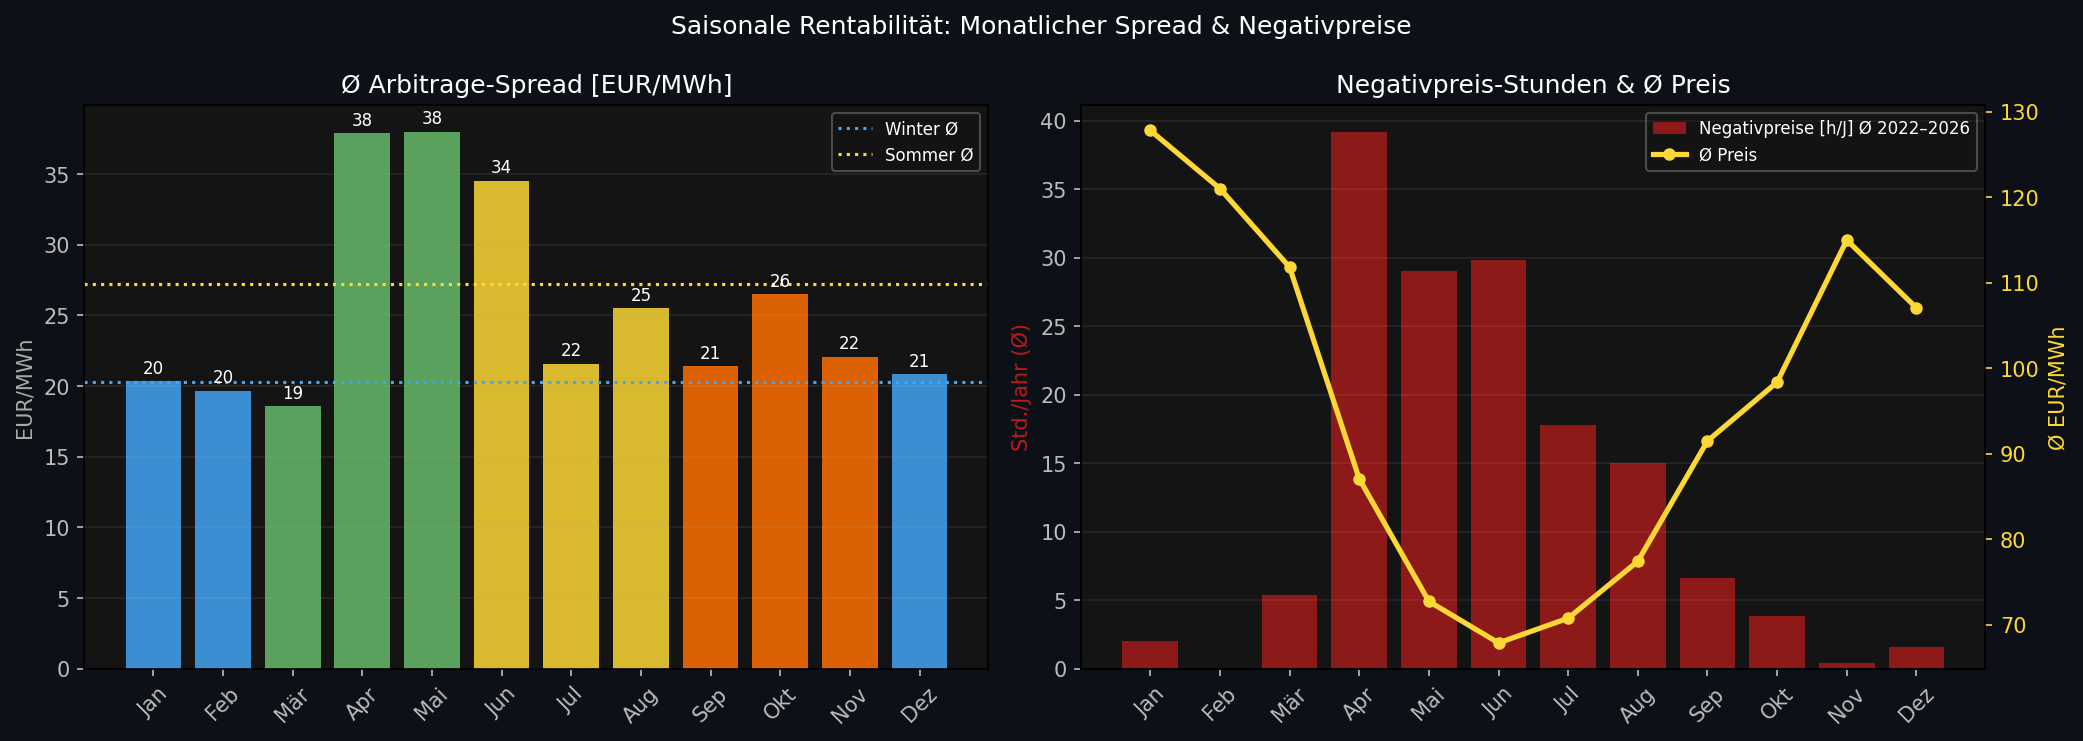


Monatlicher Arbitrage-Spread & Negativpreis-Stunden



In [22]:
show_chart('nb04_saisonal_roi.png',
           'Monatlicher Arbitrage-Spread & Negativpreis-Stunden', width=900)

---

### 3.6 Grenzen der reinen Arbitrage

Die Ergebnisse in 3.3–3.5 beschreiben **reine Grid-Arbitrage** unter aktuellen CH-Marktbedingungen. Mehrere Parameter können den Business Case wesentlich verbessern — sie sind nicht Gegenstand dieses Pflicht-Notebooks, werden aber in den Kür-Notebooks systematisch untersucht:

- **Steigender Spread / sinkende CAPEX** → verbessert [ROI](../organisation/O_02_Glossar.ipynb#g-roi) direkt
- **Erlösstacking** (FCR/aFRR/VPP) → Erlösquellen neben Arbitrage
- **DA-optimaler Dispatch** → höhere Ausnutzung der Preisspitzen
- **Standortwahl nach BVI** → Netzentlastungswert steigt bei richtiger Zone
- **Andere Technologien & Eigenverbrauch** → andere Kostenstruktur, andere Amortisationslogik

> Die strategische Synthese aller Faktoren — unter welchen Bedingungen [Grid-Arbitrage](../organisation/O_02_Glossar.ipynb#g-grid-arbitrage) wirtschaftlich sinnvoll wird — liefert **[K_00 – Business Strategy](../kuer/K_00_Business_Strategy.ipynb)** (Kür-Notebook, Ordner `kuer/`).


## Fazit und Empfehlungen <a id='fazit-und-empfehlungen_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

**Grid-Arbitrage ist technisch realisierbar, bei aktuellen CH Marktpreisen aber noch nicht rentabel.** Kein Segment erreicht den Ziel-[ROI](../organisation/O_02_Glossar.ipynb#g-roi) von 8.33%⚙ p.a. (= 100 / 12 Jahre⚙ Lebensdauer) durch reine Arbitrage:

| Segment | ROI (Arbitrage) | Break-Even | Bewertung |
|---------|----------------|------------|-----------|
| Privat 10 kWh | 1.8%📊 | > 20 Jahre📊 | Nicht rentabel |
| Gewerbe 100 kWh | 3.1%📊 | > 20 Jahre📊 | Nicht rentabel |
| Industrie 1 MWh | 4.6%📊 | > 20 Jahre📊 | Nächste am Ziel |
| Utility 10 MWh | 3.0%📊 | > 20 Jahre📊 | Nicht rentabel |

**Hauptursache:** Der Schweizer Day-Ahead Spread (~19–38 EUR/MWh je Monat) ist zu gering um [CAPEX](../organisation/O_02_Glossar.ipynb#g-capex) von 180–400 EUR/kWh⚙ in der modellierten Lebensdauer zurückzuverdienen.

**Wann kippt der Business Case?** Mehrere Parameter können den Business Case wesentlich verbessern (Abschnitt 3.6): steigender Spread, sinkende CAPEX, [Erlösstacking](../organisation/O_02_Glossar.ipynb#g-erloess-stacking), DA-optimaler [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch) und standortbasierter Netzwert. Eine vollständige Szenarienanalyse über alle diese Faktoren liefert **[K_00 – Business Strategy](../kuer/K_00_Business_Strategy.ipynb)** — das Kür-Notebook das alle Einzelanalysen aus `kuer/` zusammenführt.

> Weiterführende strategische Empfehlungen und räumliche Optimierung: → [K_00 – Business Strategy](../kuer/K_00_Business_Strategy.ipynb)

---
*Daten: [ENTSO-E](../organisation/O_02_Glossar.ipynb#g-entsoe) Transparency Platform (DL-DE-BY-2.0) · ENTSO-E query\_load (Netzlast).*  
*Kür-Analysen (K_00–K_11 in `kuer/`): Business Strategy, Räumliche Analyse, Cross-Border, Marktdynamik, Animationen, [Revenue Stacking](../organisation/O_02_Glossar.ipynb#g-erloess-stacking), Dispatch, Technologievergleich, Alternative Speicher, Eigenverbrauch, Produktsteckbrief, Kombinierte Simulation.*


---

## Kür-Erweiterungen <a id='kuer-erweiterungen_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

Die folgenden Notebooks vertiefen den Business Case um weitere Analysedimensionen. Sie liegen im Ordner **`kuer/`** und setzen die Pflicht-Notebooks (`notebooks/NB01–NB04`) voraus — Daten und Zwischenergebnisse fliessen via `../sync/transfer.json` oder `../data/`.

**Einstiegspunkt:** [K_00 – Business Strategy](../kuer/K_00_Business_Strategy.ipynb) fasst alle Kür-Analysen strategisch zusammen.

| Notebook | Inhalt |
|----------|--------|
| [K_00 – Business Strategy](../kuer/K_00_Business_Strategy.ipynb) | Synthese aller Kür-Analysen: Trigger-Matrix, Szenarien, Empfehlungen je Segment | ← Einstieg |
| [K_01 – Räumliche Analyse](../kuer/K_01_Raeumliche_Analyse.ipynb) | [BVI](../organisation/O_02_Glossar.ipynb#g-bvi), Zonenbilanzen, Standortoptimierung — wo lohnen sich Batterien räumlich? | |
| [K_02 – Cross-Border-Analyse](../kuer/K_02_Cross_Border.ipynb) | Grenzflüsse CH↔DE/AT/IT/FR — empirische Validierung des Business Case | |
| [K_03 – Marktdynamik](../kuer/K_03_Marktdynamik.ipynb) | Spread-Entwicklung 2018–2024, [CAPEX](../organisation/O_02_Glossar.ipynb#g-capex)-Lernkurve bis 2035 | |
| [K_04 – Saisonale Animationen](../kuer/K_04_Animationen.ipynb) | Animierter Jahresverlauf: Spread, Netzlast, Arbitrage-Fenster als GIF | |
| [K_05 – Revenue Stacking](../kuer/K_05_Revenue_Stacking.ipynb) | [VPP](../organisation/O_02_Glossar.ipynb#g-vpp), FCR/aFRR, Smart Tariff — Erlösquellen neben reiner Arbitrage | |
| [K_06 – Dispatch-Optimierung](../kuer/K_06_Dispatch_Optimierung.ipynb) | Day-Ahead-optimaler [Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch) vs. reaktives Schwellenwertmodell | |
| [K_07 – Technologievergleich](../kuer/K_07_Technologievergleich.ipynb) | LFP, [NMC](../organisation/O_02_Glossar.ipynb#g-nmc), [NaS](../organisation/O_02_Glossar.ipynb#g-nas), [Redox-Flow](../organisation/O_02_Glossar.ipynb#g-redox-flow), Pumpspeicher: Profil und Segmenteignung | |
| [K_08 – Alternative Speicher](../kuer/K_08_Alternative_Speicher.ipynb) | Pumpspeicher, [CAES](../organisation/O_02_Glossar.ipynb#g-caes), [Power-to-X](../organisation/O_02_Glossar.ipynb#g-power-to-x) — andere Kostenstruktur, andere Regulierung | |
| [K_09 – Eigenverbrauchsoptimierung](../kuer/K_09_Eigenverbrauch.ipynb) | Netz-Eigenverbrauch als Alternative und Ergänzung zur [Grid-Arbitrage](../organisation/O_02_Glossar.ipynb#g-grid-arbitrage) | |
| [K_10 – Produktsteckbrief](../kuer/K_10_Produkt_Steckbrief.ipynb) | Heimspeicher 7 kW / 4 kWh: konkreter Business Case Arbitrage + Eigenverbrauch | |
| [K_99 – Kombinierte Simulation](../kuer/K_99_Kombinierte_Simulation.ipynb) | Hybrid-Dispatch: Arbitrage + Eigenverbrauch — 4-Strategie-Vergleich | |


---
## Abschluss <a id='abschluss_NB_00'></a>

[↑ Inhaltsverzeichnis](#toc_NB_00)

Pflicht-Charts aus `output/charts/` auf Existenz prüfen.
Fehlende Charts: NB03 erneut ausführen.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `pipeline_overview` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar.


In [23]:
show_source(pipeline_overview)

<details>
<summary>🔎 Quellcode: <code>pipeline_overview</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def pipeline_overview(nb_label, sections, *, weiter_msg=None, width=60):
    """Mehr-Sektionen-Übersicht für Übersichts-NBs (NB00, K_00).

    Im Gegensatz zu :func:`final_check` zeigt diese Funktion mehrere benannte
    Sektionen mit eigenem Header, jede mit einer Liste von Dateien oder einer
    automatischen Verzeichnis-Auflistung.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks, z.B. ``"NB00"``.
    sections : list of tuple
        Liste von ``(header, items)``-Tuples. ``items`` ist eine Liste von:

        * ``(path, label, min_bytes)`` — einzelne Datei (wie ``final_check``)
        * ``(path, label, min_bytes, 'file')`` — explizit Datei
        * ``(path, '', 0, 'dir_listing')`` — listet alle Files im Verzeichnis
          ``path`` auf (alphabetisch, mit Grösse). ``label`` wird ignoriert.

        Mischung aus mehreren Item-Typen pro Sektion ist erlaubt.
    weiter_msg : str, optional
        Nachricht für den Weiter-Hinweis am Ende.
    width : int, default 60
        Breite der Trennlinie.

    Return
    ------
    bool
        ``True`` wenn alle einzeln gelisteten Files OK sind. Bei ``dir_listing``
        wird Existenz des Verzeichnisses geprüft, der Inhalt aber nicht
        gegen Erwartungen verglichen (es wird gezeigt was da ist).
    """
    print(f'{nb_label} – Abschluss')
    print('=' * width)

    all_ok = True

    for header, items in sections:
        print(f'\n{header}:')

        for item in items:
            if len(item) == 4:
                path, label, min_bytes, kind = item
            else:
                path, label, min_bytes = item
                kind = 'file'

            if kind == 'dir_listing':
                if os.path.exists(path):
                    files_in_dir = sorted(f for f in os.listdir(path)
                                          if os.path.isfile(os.path.join(path, f)))
                    if not files_in_dir:
                        print(f'  ⚠️   (Verzeichnis ist leer)')
                    for f in files_in_dir:
                        fpath = os.path.join(path, f)
                        size_str = _format_size(os.path.getsize(fpath))
                        print(f'  ✅  {f:<45} {size_str}')
                    print(f'  {len(files_in_dir)} Datei(en) vorhanden')
                else:
                    print(f'  ❌  Verzeichnis nicht vorhanden: {path}')
                    all_ok = False

            else:  # kind == 'file'
                exists = os.path.exists(path)
                size = os.path.getsize(path) if exists else 0
                ok = exists and size >= min_bytes

                if min_bytes > 0:
                    size_str = _format_size(size) if exists else '   FEHLT'
                    print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
                else:
                    print(f'  {"✅" if ok else "❌"}  {label}')

                if not ok:
                    all_ok = False

    if weiter_msg:
        print(f'\n→ Weiter mit {weiter_msg}.')

    return all_ok
```

</details>


In [24]:
# ── Abschluss-Übersicht ──────────────────────────────────────────────────────
DIR_INTER = os.path.join('../data', 'intermediate', SZ_AKTIV)

pipeline_overview(
    f'NB00 (Szenario: {SZ_AKTIV})',
    sections=[
        ('Notebooks (Pflicht)', [
            (nb, nb, 0) for nb in [
                '01_Daten_Laden.ipynb', '02_Daten_Bereinigung.ipynb',
                '03_Daten_Analyse.ipynb', '04_Visualisierungen.ipynb',
            ]
        ]),
        (f'Zwischenergebnisse ({DIR_INTER})', [(DIR_INTER,  '', 0, 'dir_listing')]),
        (f'Charts ({CHARTS_DIR})',            [(CHARTS_DIR, '', 0, 'dir_listing')]),
    ],
    weiter_msg='K_00 Business Strategy (Kür)',
)

NB00 (Szenario: realistisch) – Abschluss

Notebooks (Pflicht):
  ✅  01_Daten_Laden.ipynb
  ✅  02_Daten_Bereinigung.ipynb
  ✅  03_Daten_Analyse.ipynb
  ✅  04_Visualisierungen.ipynb

Zwischenergebnisse (../data\intermediate\realistisch):
  ✅  netzentlastung_szenarien.csv                      0.4 KB
  ✅  wirtschaftlichkeit.csv                            0.6 KB
  2 Datei(en) vorhanden

Charts (../output\charts\realistisch):
  ✅  chart7a_spread_trend.png                         82.1 KB
  ✅  chart7b_volatilitaet.png                         75.7 KB
  ✅  kuer_k01_anim_4zeitpunkte.png                    46.3 KB
  ✅  kuer_k01_anim_tagesverlauf.gif                  753.6 KB
  ✅  kuer_k01_bvi_heatmap.png                         71.7 KB
  ✅  kuer_k01_bvi_jahresdurchschnitt.png              66.6 KB
  ✅  kuer_k01_bvi_saisonal.png                       117.0 KB
  ✅  kuer_k01_heatmap_lastprofil.png                 153.3 KB
  ✅  kuer_k01_heatmap_produktionsmix.png             248.6 KB
  ✅  kuer_k01_kart

True

| [← NB04 Visualisierungen](04_Visualisierungen.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [NB01 Daten Laden →](01_Daten_Laden.ipynb) |
|:---|:---:|---:|